# 消费红利股票多因子选股策略

> 研究底稿 | 面向私募基金经理的量化策略验证

本 notebook 保留可复现的研究链条：数据审计、口径验证、因子构建、单因子检验、组合回测、稳健性检验和图表导出。结论以代码输出的表格和图表为依据，完整报告见 `report.md`。

**数据范围**：月频 | 2013-08 ~ 2022-11 | A 股消费行业 261 只 | `code / close / divi / cap / date`
**收益口径**：价格收益，不含现金分红
**主策略**：DY(规模中性)；增强方案 `0.7×DY_neut + 0.3×Rev`


In [1]:
# Cell 1: 环境初始化
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from IPython.display import display
import os, warnings, json
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
os.makedirs('assets', exist_ok=True)
os.makedirs('output', exist_ok=True)

---
## 1. 数据加载与口径核验

### 1.1 数据概览

确认样本范围、字段可用性和每月投资域。后续回测均采用动态样本池：`close.notna() & cap > 0`。


项目,结果
原始记录数,"29,232 行"
股票数量,261 只
月份数量,112 个月
日期范围,2013-08-01 ~ 2022-11-01
首月有效样本,135 只
末月有效样本,259 只


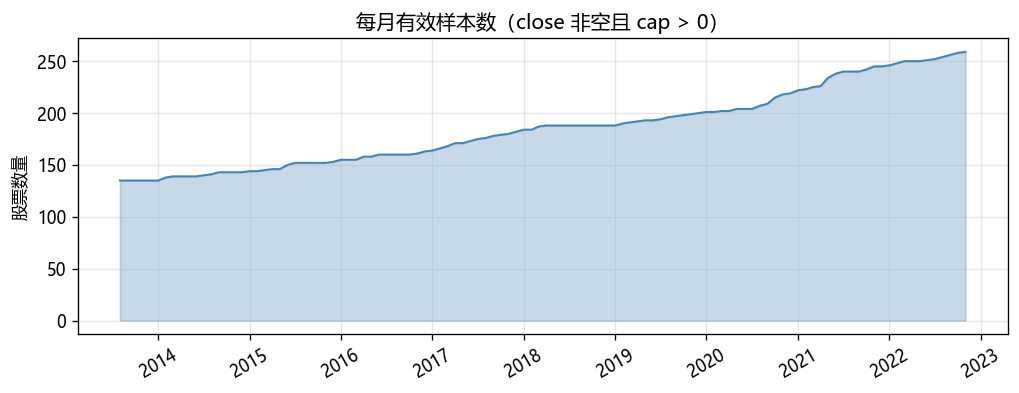

In [2]:
# Cell 2: 加载数据 + 有效样本统计
df = pd.read_csv('data/consume.csv')
df['date'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d')

df['valid'] = df['close'].notna() & (df['cap'] > 0)
monthly_counts = df.groupby('date')['valid'].sum()

data_overview = pd.DataFrame([
    ['原始记录数', f'{df.shape[0]:,} 行'],
    ['股票数量', f'{df.code.nunique()} 只'],
    ['月份数量', f'{df.date.nunique()} 个月'],
    ['日期范围', f'{df.date.min().date()} ~ {df.date.max().date()}'],
    ['首月有效样本', f'{monthly_counts.iloc[0]} 只'],
    ['末月有效样本', f'{monthly_counts.iloc[-1]} 只'],
], columns=['项目', '结果'])
data_overview.to_csv('output/table_data_overview.csv', index=False, encoding='utf-8-sig')
display(data_overview.style.hide(axis='index').set_caption('数据概览').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.fill_between(monthly_counts.index, monthly_counts.values, alpha=0.3, color='steelblue')
ax.plot(monthly_counts.index, monthly_counts.values, linewidth=1.2, color='steelblue')
ax.set_title('每月有效样本数（close 非空且 cap > 0）', fontsize=12)
ax.set_ylabel('股票数量')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)
fig.savefig('assets/fig_01_monthly_valid.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 股息率字段验证

核心问题：`divi` 是月度股息率快照还是分红事件标识？通过 DPS 代理值稳定性和 close-divi 负相关性来判别。


检验项,结果
divi 原始覆盖率,48.8%
divi 中位数,0.86%
divi 75%分位,1.49%
divi 99%分位,6.80%
DPS 相邻月变化中位数,0.000000
DPS 相邻月变化 <0.01 占比,92.7%
close-divi 相关系数中位数,-0.50
close-divi 负相关占比,80%


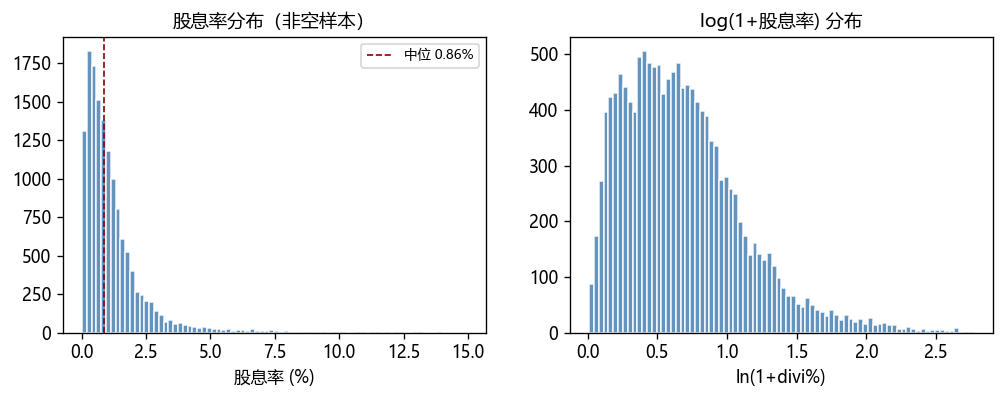

In [3]:
# Cell 3: divi 分布与口径验证
divi_valid = df['divi'].dropna()

# 验证：divi = 固定DPS / 变动close
codes_check = df['code'].drop_duplicates().sample(n=min(20, df['code'].nunique()), random_state=42).tolist()
df_check = df[df['code'].isin(codes_check) & df['divi'].notna()].copy()
df_check['dps'] = df_check['close'] * df_check['divi'] / 100
dps_diff_abs = df_check.groupby('code')['dps'].diff().dropna().abs()

corrs = [df[df['code']==c].dropna(subset=['close','divi'])[['close','divi']].corr().iloc[0,1]
         for c in codes_check if len(df[df['code']==c].dropna(subset=['close','divi'])) > 20]
corrs_arr = np.array(corrs)

divi_audit = pd.DataFrame([
    ['divi 原始覆盖率', f'{df.divi.notna().mean():.1%}'],
    ['divi 中位数', f'{divi_valid.median():.2f}%'],
    ['divi 75%分位', f'{divi_valid.quantile(0.75):.2f}%'],
    ['divi 99%分位', f'{divi_valid.quantile(0.99):.2f}%'],
    ['DPS 相邻月变化中位数', f'{dps_diff_abs.median():.6f}'],
    ['DPS 相邻月变化 <0.01 占比', f'{(dps_diff_abs < 0.01).mean():.1%}'],
    ['close-divi 相关系数中位数', f'{np.median(corrs_arr):.2f}' if len(corrs_arr) else '-'],
    ['close-divi 负相关占比', f'{(corrs_arr < 0).mean():.0%}' if len(corrs_arr) else '-'],
], columns=['检验项', '结果'])
divi_audit.to_csv('output/table_divi_audit.csv', index=False, encoding='utf-8-sig')
display(divi_audit.style.hide(axis='index').set_caption('divi 字段口径验证').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(divi_valid, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(divi_valid.median(), color='darkred', linestyle='--', lw=1, label=f'中位 {divi_valid.median():.2f}%')
axes[0].set_title('股息率分布（非空样本）', fontsize=11)
axes[0].set_xlabel('股息率 (%)')
axes[0].legend(fontsize=8)
axes[1].hist(np.log1p(divi_valid), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('log(1+股息率) 分布', fontsize=11)
axes[1].set_xlabel('ln(1+divi%)')
fig.savefig('assets/fig_02_divi_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 DY 因子构建

`divi` 不能直接前向填充——那样会把旧价格下的股息率冻结到后续月。正确做法：先还原每股现金分红代理值 → 前向填充 DPS → 除以当月收盘价。


In [4]:
# Cell 4: DY 构建路线对比
df_t = df[df['valid']].copy()
df_t['dps_proxy'] = df_t['close'] * df_t['divi'] / 100
df_t['dps_ffill'] = df_t.groupby('code')['dps_proxy'].ffill()
df_t['dy_correct'] = df_t['dps_ffill'] / df_t['close'] * 100
df_t['dy_wrong'] = df_t.groupby('code')['divi'].ffill()
diff = (df_t['dy_wrong'] - df_t['dy_correct']).dropna().abs()

df['dps'] = df['close'] * df['divi'] / 100
df['dps_ff'] = df.groupby('code')['dps'].ffill()
df['dy_final'] = df['dps_ff'] / df['close'] * 100

dy_method_audit = pd.DataFrame([
    ['差异 > 0.1pct 的样本占比', f'{(diff > 0.1).mean():.1%}'],
    ['最大差异', f'{diff.max():.2f} pct'],
    ['divi 原始覆盖率', f'{df["divi"].notna().mean():.1%}'],
    ['DY 修正后覆盖率', f'{df["dy_final"].notna().mean():.1%}'],
], columns=['检验项', '结果'])
dy_method_audit.to_csv('output/table_dy_method_audit.csv', index=False, encoding='utf-8-sig')
display(dy_method_audit.style.hide(axis='index').set_caption('DY 构建路线验证').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

检验项,结果
差异 > 0.1pct 的样本占比,10.5%
最大差异,7.55 pct
divi 原始覆盖率,48.8%
DY 修正后覆盖率,60.4%


直接填充 `divi` 会把旧价格下的股息率冻结到后续月份，对横截面排序造成可见扰动。后续统一使用 `dps_proxy → ffill → /close` 口径，并禁止 `bfill`。


---
## 2. 因子构建

### 2.1 分析面板与收益计算

**关键处理顺序**：先基于完整 close 序列计算跨期收益，再按 `cap > 0` 筛选投资域。若先过滤 cap 缺失再计算收益，会导致某些股票的跨期收益错位（t 月 cap 缺失但 close 有效，t+1 月 cap 恢复时收益链接错误）。


In [5]:
# Cell 5: 构建分析面板 + 收益计算
panel = df[['code','date','close','divi','cap']].copy()
panel = panel[panel['close'].notna()].sort_values(['code','date']).reset_index(drop=True)

# 先计算跨期收益（全 close 序列）
panel['price_ret'] = panel.groupby('code')['close'].transform(lambda x: x.shift(-1) / x - 1)
panel['lag_ret'] = panel.groupby('code')['close'].transform(lambda x: x / x.shift(1) - 1)

# 再按 t 月投资域筛选
panel = panel[panel['cap'] > 0].reset_index(drop=True)

# 红利因子
panel['dps_proxy'] = panel['close'] * panel['divi'] / 100
panel['dps_ffill'] = panel.groupby('code')['dps_proxy'].ffill()
panel['dy'] = panel['dps_ffill'] / panel['close'] * 100

panel['has_divi'] = panel['divi'].notna().astype(float)
panel['divi_stability'] = panel.groupby('code')['has_divi'].transform(
    lambda x: x.rolling(60, min_periods=24).mean())
panel.drop(columns=['has_divi'], inplace=True)

panel['dps_growth'] = panel.groupby('code')['dps_ffill'].transform(lambda x: x / x.shift(12) - 1)
panel['dy_yoy'] = panel.groupby('code')['dy'].transform(lambda x: x / x.shift(12) - 1)
panel['ln_cap'] = np.log(panel['cap'])

# 规模中性化 DY：每月截面内做 dy ~ ln_cap 回归，取残差并加回截距。
def _neutralize_size(grp):
    valid = grp['dy'].notna() & grp['ln_cap'].notna()
    if valid.sum() < 15:
        return pd.Series(np.nan, index=grp.index)
    y = grp.loc[valid, 'dy'].values
    X = grp.loc[valid, 'ln_cap'].values.reshape(-1, 1)
    X = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    result = pd.Series(np.nan, index=grp.index)
    result.loc[valid] = resid + beta[0]
    return result

panel['dy_neutral'] = panel.groupby('date', group_keys=False).apply(_neutralize_size)

panel_audit = pd.DataFrame([
    ['分析面板记录数', f'{panel.shape[0]:,} 行'],
    ['股票数量', f'{panel.code.nunique()} 只'],
    ['月份数量', f'{panel.date.nunique()} 个月'],
    ['price_ret 覆盖率', f'{panel["price_ret"].notna().mean():.1%}'],
    ['DY 覆盖率', f'{panel["dy"].notna().mean():.1%}'],
    ['DY(规模中性) 覆盖率', f'{panel["dy_neutral"].notna().mean():.1%}'],
], columns=['项目', '结果'])
panel_audit.to_csv('output/table_panel_audit.csv', index=False, encoding='utf-8-sig')
display(panel_audit.style.hide(axis='index').set_caption('分析面板检查').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

项目,结果
分析面板记录数,"20,791 行"
股票数量,259 只
月份数量,112 个月
price_ret 覆盖率,98.8%
DY 覆盖率,84.9%
DY(规模中性) 覆盖率,84.9%


### 2.2 动量/反转因子

基于 `lag_ret`（已知最近一期月收益）构建价格类因子。`rev_1m` 直接取 `lag_ret`，即 t 月末已知的最近一月收益，确保无未来函数。所有滚动因子使用 t 月之前的窗口，不含当期信息。


In [6]:
# Cell 6: 动量/反转因子（基于 lag_ret，无未来函数）
def rolling_factor(group, window, fn):
    vals = group.values
    out = np.full(len(vals), np.nan)
    for i in range(window, len(vals)):
        seg = vals[i-window:i]
        seg = seg[~np.isnan(seg)]
        if len(seg) >= max(3, window//2):
            out[i] = fn(seg)
    return pd.Series(out, index=group.index)

for c in panel['code'].unique():
    idx = panel['code'] == c
    rets = panel.loc[idx, 'lag_ret'].copy()
    panel.loc[idx, 'rev_1m'] = rets
    # 平滑反转：过去 3 个月 lag_ret 均值（降低单月噪声，减少换手）
    panel.loc[idx, 'rev_smooth'] = rolling_factor(rets, 3, lambda x: np.mean(x)).values
    panel.loc[idx, 'mom_6m'] = rolling_factor(rets, 6, lambda x: np.prod(1+x)-1).values
    panel.loc[idx, 'rev_12m'] = rolling_factor(rets, 12, lambda x: np.prod(1+x)-1).values
    panel.loc[idx, 'lowvol_12m'] = rolling_factor(rets, 12, lambda x: np.std(x)).values

ALL_FACTORS = ['dy','dy_neutral','divi_stability','dps_growth','dy_yoy','ln_cap','rev_1m','rev_smooth','mom_6m','rev_12m','lowvol_12m']
FACTOR_LABEL = {
    'dy': '股息率 DY', 'divi_stability': '红利稳定性', 'dps_growth': 'DPS增长',
    'dy_yoy': 'DY同比变化', 'ln_cap': 'ln(市值)', 'rev_1m': '短期反转',
    'dy_neutral': 'DY(规模中性)', 'rev_smooth': '平滑反转',
    'mom_6m': '中期动量', 'rev_12m': '长期反转', 'lowvol_12m': '低波动'
}
FACTOR_DIR = {
    'dy': 1, 'divi_stability': 1, 'dps_growth': 1, 'dy_yoy': 1, 'ln_cap': -1,
    'rev_1m': -1, 'dy_neutral': 1, 'rev_smooth': -1, 'mom_6m': 1, 'rev_12m': -1, 'lowvol_12m': -1
}

cov_tbl = pd.DataFrame({
    '因子': [FACTOR_LABEL[f] for f in ALL_FACTORS],
    '覆盖率': [f'{panel[f].notna().mean():.1%}' for f in ALL_FACTORS],
    '方向': ['正向' if FACTOR_DIR[f] > 0 else '反向' for f in ALL_FACTORS]
})
display(cov_tbl.style.set_caption('因子覆盖率一览').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,因子,覆盖率,方向
0,股息率 DY,84.9%,正向
1,DY(规模中性),84.9%,正向
2,红利稳定性,73.1%,正向
3,DPS增长,71.8%,正向
4,DY同比变化,71.8%,正向
5,ln(市值),100.0%,反向
6,短期反转,98.8%,反向
7,平滑反转,95.1%,反向
8,中期动量,92.6%,正向
9,长期反转,85.5%,反向


### 2.3 因子库一览

| 类别 | 因子 | 构建方式 | 经济逻辑 | 方向 |
|---|---|---|---|---|
| 红利 | 股息率 DY | dps_ffill / close × 100 | 高股息反映现金回报与估值约束 | + |
| 红利 | DY(规模中性) | dy 对 ln_cap 月度截面回归残差 | 剥离小盘效应后的纯红利信号 | + |
| 红利 | 红利稳定性 | 60 个月 divi 非空占比 | 持续分红优于一次性高分红 | + |
| 红利 | DPS 增长 | dps_ffill / dps_ffill.shift(12) − 1 | 每股分红增长代表红利质量 | + |
| 红利 | DY 同比变化 | dy / dy.shift(12) − 1 | 股息率变化的综合效应 | + |
| 规模 | ln(市值) | ln(cap) | A 股小盘溢价效应 | − |
| 动量 | 短期反转 | t 月已知的最近一月收益 | A 股短期反转效应 | − |
| 动量 | 平滑反转 | 过去 3 个月已知收益均值 | 降低单月噪声和换手 | − |
| 动量 | 中期动量 | 过去 6 个月累计收益 − 1 | 中期趋势延续 | + |
| 动量 | 长期反转 | 过去 12 个月累计收益 − 1 | 长期反转效应 | − |
| 低波 | 低波动 | 过去 12 个月收益标准差 | 低波异象 | − |

**排除项**：EP、BM、日度低波、换手率、流动性和含息总收益均缺少必要字段，不进入实证。


---
## 3. 单因子检验


In [7]:
# Cell 7: 单因子 IC/RankIC + 分组回测
def single_factor_test(panel, factor, direction, n_groups=5):
    df = panel[panel[factor].notna() & panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    ic_list, ric_list, g1_rets, g5_rets = [], [], [], []
    for m in months:
        dm = df[df['date'] == m]
        if len(dm) < n_groups: continue
        fv = dm[factor].values * direction
        rv = dm['price_ret'].values
        ic = np.corrcoef(fv, rv)[0, 1]
        ric = stats.spearmanr(fv, rv)[0]
        if not np.isnan(ic): ic_list.append(ic)
        if not np.isnan(ric): ric_list.append(ric)
        dm = dm.copy()
        dm['rank'] = dm[factor].rank(pct=True)
        dm['g'] = pd.cut(dm['rank'], bins=n_groups, labels=False) + 1
        if direction > 0:
            g1_rets.append(dm[dm['g'] == n_groups]['price_ret'].mean())
            g5_rets.append(dm[dm['g'] == 1]['price_ret'].mean())
        else:
            g1_rets.append(dm[dm['g'] == 1]['price_ret'].mean())
            g5_rets.append(dm[dm['g'] == n_groups]['price_ret'].mean())
    g1a = np.array(g1_rets); g5a = np.array(g5_rets); ls = g1a - g5a
    t_stat = stats.ttest_1samp(ls, 0)[0] if len(ls) > 1 else np.nan
    ic_arr = np.array(ic_list); ric_arr = np.array(ric_list)
    return {
        '因子': FACTOR_LABEL.get(factor, factor),
        'G1月均收益': np.mean(g1a), 'G5月均收益': np.mean(g5a),
        '多空差值': np.mean(ls), '多空t值': t_stat,
        'IC Mean': np.mean(ic_arr), 'IC Std': np.std(ic_arr),
        'RankIC Mean': np.mean(ric_arr), 'RankIC IR': np.mean(ric_arr)/np.std(ric_arr) if np.std(ric_arr) > 1e-12 else np.nan,
        'IC>0占比': np.mean(ic_arr > 0), 'N': len(ic_list)
    }

factor_results = [single_factor_test(panel, f, FACTOR_DIR[f]) for f in ALL_FACTORS]
ftbl = pd.DataFrame(factor_results)
ftbl.to_csv('output/table_factor_summary.csv', index=False, encoding='utf-8-sig')

# 格式化展示
disp = ftbl[['因子', 'G1月均收益', '多空差值', '多空t值', 'IC Mean', 'RankIC Mean', 'IC>0占比']].copy()
disp['G1月均收益'] = disp['G1月均收益'].apply(lambda x: f'{x:.2%}')
disp['多空差值'] = disp['多空差值'].apply(lambda x: f'{x:.2%}')
disp['多空t值'] = disp['多空t值'].apply(lambda x: f'{x:.2f}')
disp['IC Mean'] = disp['IC Mean'].apply(lambda x: f'{x:.4f}')
disp['RankIC Mean'] = disp['RankIC Mean'].apply(lambda x: f'{x:.4f}')
disp['IC>0占比'] = disp['IC>0占比'].apply(lambda x: f'{x:.1%}')
display(disp.style.set_caption('单因子检验结果汇总').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,因子,G1月均收益,多空差值,多空t值,IC Mean,RankIC Mean,IC>0占比
0,股息率 DY,1.68%,1.00%,2.67,0.0190,0.0516,55.9%
1,DY(规模中性),1.77%,1.04%,3.23,0.0232,0.0503,58.6%
2,红利稳定性,0.78%,0.43%,0.90,0.0228,0.0382,56.8%
3,DPS增长,1.37%,-0.04%,-0.09,-0.0089,0.0092,37.4%
4,DY同比变化,1.29%,-0.19%,-0.41,-0.0081,0.0142,48.5%
5,ln(市值),2.78%,1.63%,2.37,0.0249,0.0384,56.8%
6,短期反转,1.84%,1.46%,2.42,0.0623,0.0685,62.7%
7,平滑反转,1.45%,0.35%,0.71,0.0150,0.0218,53.3%
8,中期动量,1.56%,0.28%,0.51,0.0074,-0.0017,50.5%
9,长期反转,1.23%,-0.41%,-0.68,-0.0095,-0.0026,49.5%


### 3.1 单因子检验结果解读

结果集中在三点：DY 是红利主题中最稳定的有效因子（RankIC 和多空差均为正）；短期反转在样本内表现更强，但天然高换手，更适合作为辅助信号；ln(市值)有显著小盘效应，因此需用规模中性化 DY 来回答"红利收益是否只是小盘暴露"。


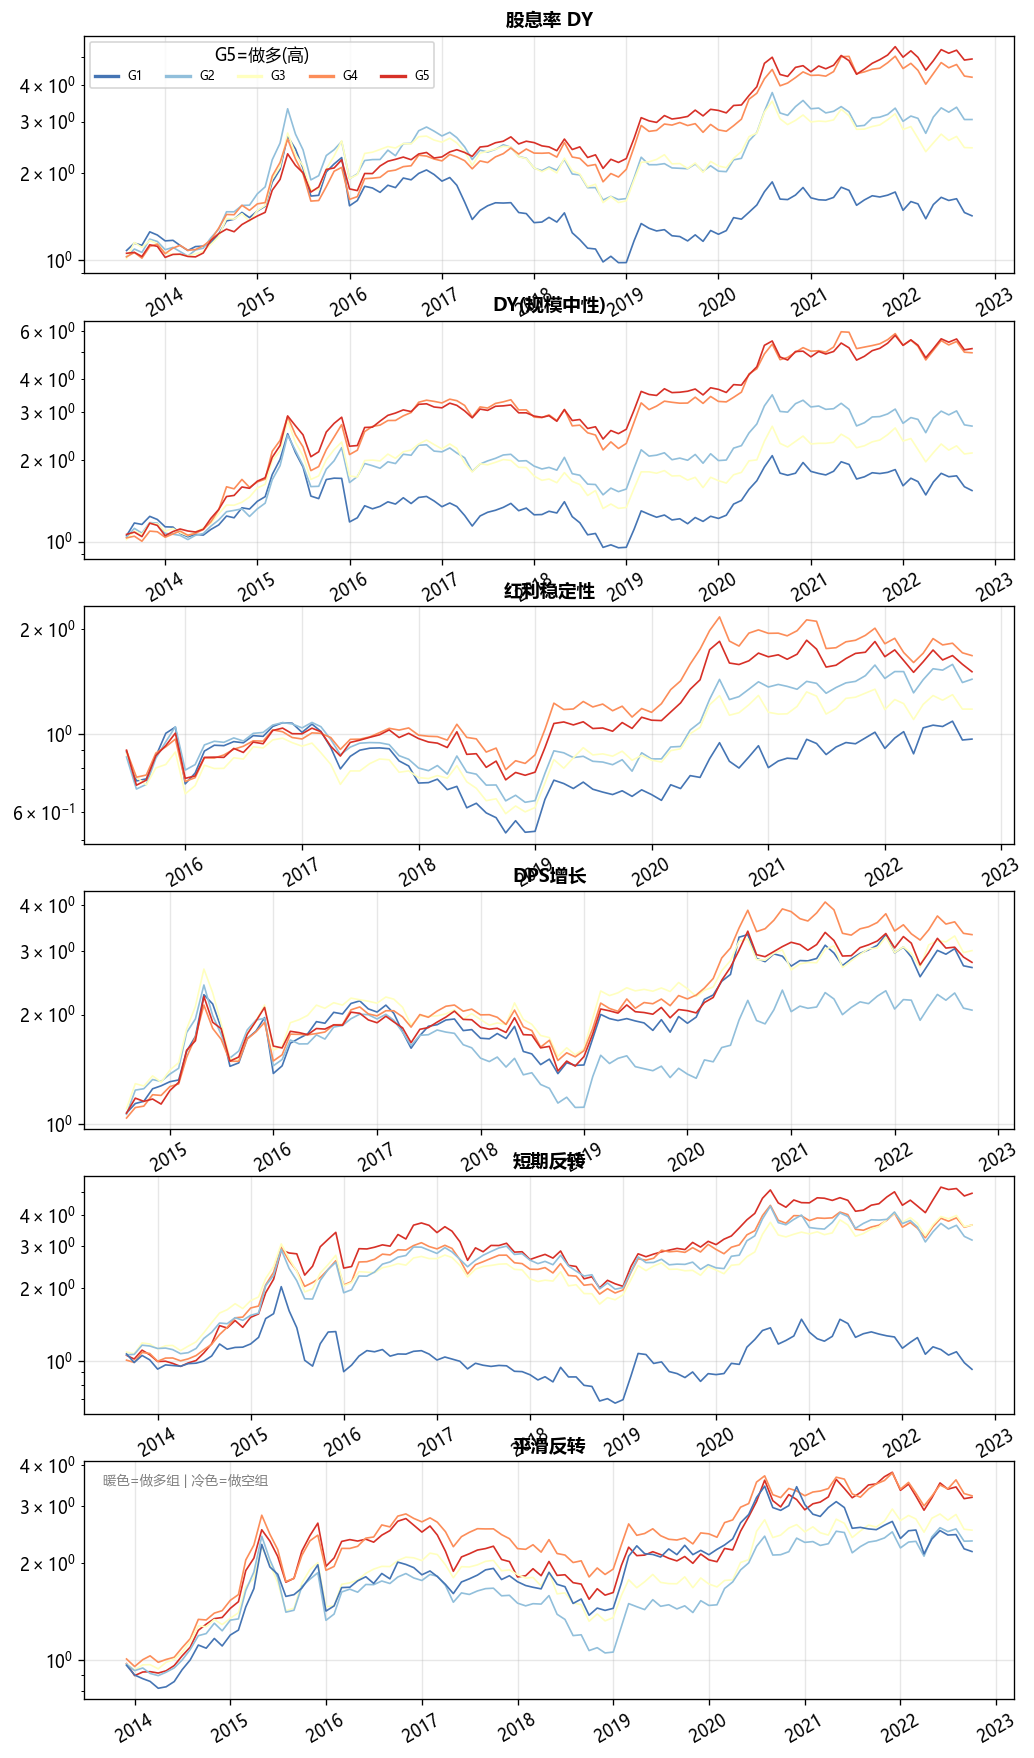

In [8]:
# Cell 8: 分组净值图（核心 6 因子，高区分度配色）
def group_nav(panel, factor, direction, n_groups=5):
    df = panel[panel[factor].notna() & panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    nv = {g: [] for g in range(1, n_groups+1)}
    dates = []
    for m in months:
        dm = df[df['date'] == m]
        if len(dm) < n_groups: continue
        dm['rank'] = dm[factor].rank(pct=True)
        dm['g'] = pd.cut(dm['rank'], bins=n_groups, labels=False) + 1
        dates.append(m)
        for g in range(1, n_groups+1):
            nv[g].append(dm[dm['g'] == g]['price_ret'].mean())
    navs = pd.DataFrame(nv, index=dates)
    if direction > 0:
        navs = navs.reindex(columns=sorted(navs.columns))
    else:
        navs = navs.reindex(columns=sorted(navs.columns, reverse=True))
    return (1 + navs).cumprod()

core5 = ['dy', 'dy_neutral', 'divi_stability', 'dps_growth', 'rev_1m', 'rev_smooth']
from matplotlib.lines import Line2D

fig, axes = plt.subplots(len(core5), 1, figsize=(10, 3.0*len(core5)))
for i, f in enumerate(core5):
    navs = group_nav(panel, f, FACTOR_DIR[f])
    ax = axes[i]
    dir_sign = FACTOR_DIR[f]
    if dir_sign > 0:
        colors = ['#4575b4','#91bfdb','#ffffbf','#fc8d59','#d73027']  # G1(short)..G5(long)
        long_label = 'G5=做多(高)'
    else:
        colors = ['#d73027','#fc8d59','#ffffbf','#91bfdb','#4575b4']  # G1(long)..G5(short)
        long_label = 'G1=做多(低)'
    for g in range(1, 6):
        ax.plot(navs.index, navs[g], linewidth=1.0, color=colors[g-1])
    ax.set_title(FACTOR_LABEL[f], fontsize=11, fontweight='bold')
    ax.set_yscale('log'); ax.grid(True, alpha=0.3); ax.tick_params(axis='x', rotation=30)
    if i == 0:
        leg_handles = [Line2D([0],[0], color=colors[j], lw=2, label=f'G{j+1}') for j in range(5)]
        ax.legend(handles=leg_handles, fontsize=7, ncol=5, loc='upper left', title=long_label)
    if i == len(core5)-1:
        ax.text(0.02, 0.95, '暖色=做多组 | 冷色=做空组', transform=ax.transAxes,
                fontsize=8, va='top', color='gray')
fig.savefig('assets/fig_03_group_nav.png', dpi=150, bbox_inches='tight')
plt.show()

分组净值的读法很直接：DY 和短期反转的高分组长期跑赢低分组，红利稳定性、DPS 增长和中期动量的层次较混乱。后续组合主要围绕 DY、DY(规模中性) 和短期反转展开。


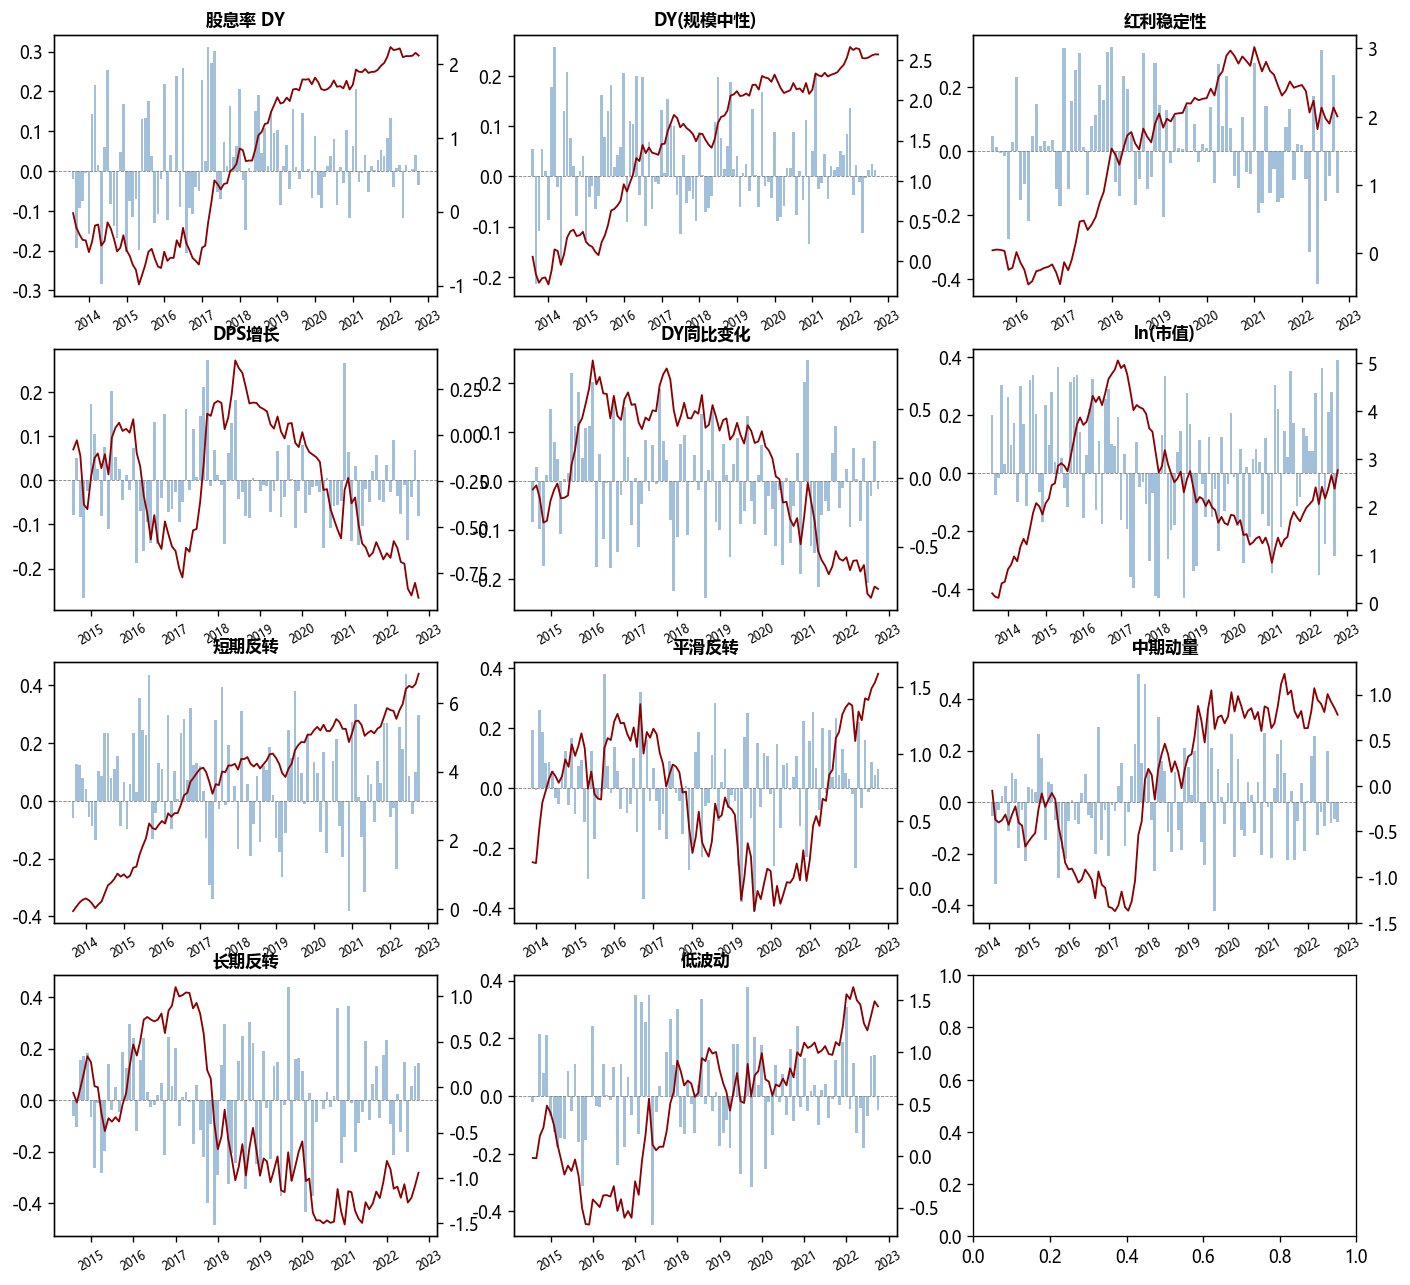

In [9]:
# Cell 9: IC 累积序列图（全部 9 因子）
fig, axes = plt.subplots(4, 3, figsize=(14, 13))
for i, f in enumerate(ALL_FACTORS):
    ax = axes.flat[i]
    df_ic = panel[panel[f].notna() & panel['price_ret'].notna()]
    ic_vals, ic_dates = [], []
    for m in sorted(df_ic['date'].unique()):
        dm = df_ic[df_ic['date'] == m]
        if len(dm) < 10: continue
        ic = np.corrcoef(dm[f].values * FACTOR_DIR[f], dm['price_ret'].values)[0, 1]
        if not np.isnan(ic):
            ic_vals.append(ic)
            ic_dates.append(m)
    ax.bar(ic_dates, ic_vals, width=25, alpha=0.5, color='steelblue', linewidth=0)
    ax2 = ax.twinx()
    ax2.plot(ic_dates, np.cumsum(ic_vals), color='darkred', linewidth=1.1)
    ax.set_title(FACTOR_LABEL[f], fontsize=10, fontweight='bold')
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
fig.savefig('assets/fig_04_ic_series.png', dpi=150, bbox_inches='tight')
plt.show()

IC 累积序列显示，DY 和短期反转的方向相对稳定；中期动量、长期反转在正负之间反复切换，不适合作为主信号。


---
## 4. 多因子合成


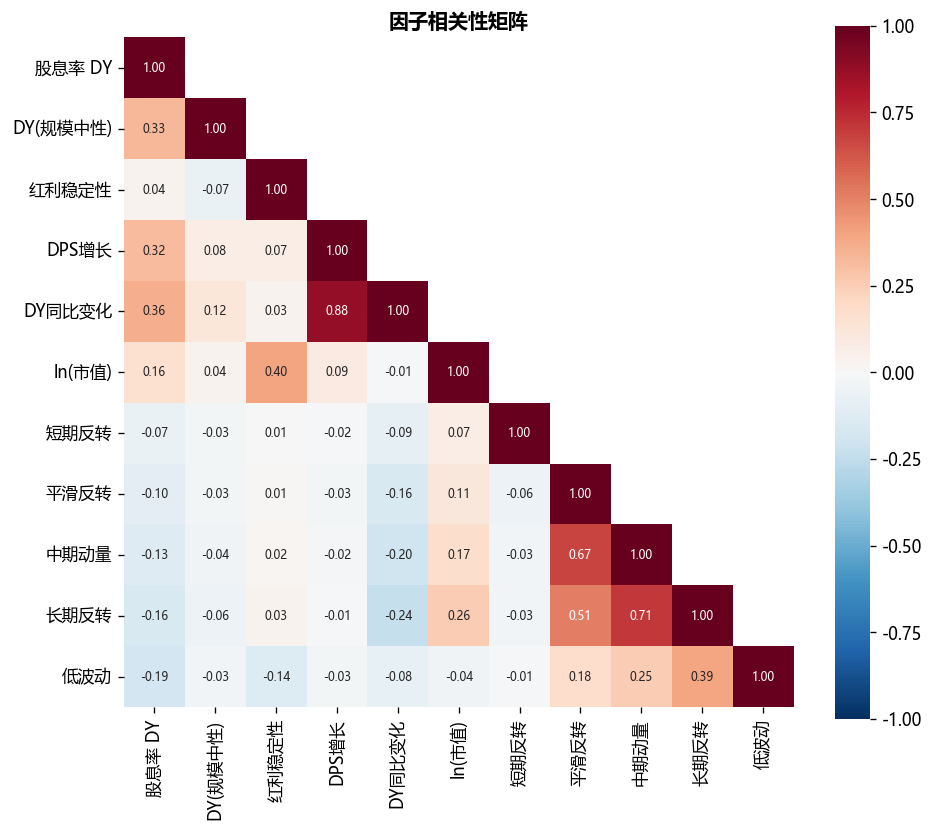

In [10]:
# Cell 10: 因子相关性矩阵
corr = panel[ALL_FACTORS].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
labels = [FACTOR_LABEL[f] for f in ALL_FACTORS]
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=ax, xticklabels=labels, yticklabels=labels, annot_kws={'fontsize': 7})
ax.set_title('因子相关性矩阵', fontsize=12, fontweight='bold')
fig.savefig('assets/fig_05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cell 11: 因子标准化 + 多因子合成
def winsorize_zscore(group, lo=0.01, hi=0.99):
    group = group.clip(group.quantile(lo), group.quantile(hi))
    mu, sig = group.mean(), group.std()
    return (group - mu) / sig if sig > 1e-12 else group - mu

def build_composite(panel, factors, directions):
    df = panel[panel['price_ret'].notna()].copy()
    scores = pd.DataFrame(index=df.index)
    for f in factors:
        if f not in df.columns: continue
        scores[f] = df.groupby('date')[f].transform(winsorize_zscore) * directions.get(f, 1)
    valid = scores.notna().all(axis=1)
    result = pd.Series(np.nan, index=df.index)
    result.loc[valid] = scores.loc[valid].mean(axis=1)
    return result

def build_composite_weighted(panel, factors, directions, ic_window=36):
    """基于滚动 36 月 IC IR 的时变因子加权合成。
    IC IR = IC_mean / IC_std，权重 = max(0, IC_IR) / sum(max(0, IC_IR))。
    当某因子近期 IC IR ≤ 0 时自动降权至零。"""
    df = panel[panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())

    scores = pd.DataFrame(index=df.index, columns=factors)
    for f in factors:
        if f not in df.columns: continue
        scores[f] = df.groupby('date')[f].transform(winsorize_zscore) * directions.get(f, 1)

    # Rolling IC IR per factor
    weights_dict = {}
    for f in factors:
        w = pd.Series(np.nan, index=months)
        for i, m in enumerate(months):
            if i < ic_window:
                continue
            wm_start = months[i - ic_window]
            wm_end = months[i - 1]
            mask = (df['date'] >= wm_start) & (df['date'] <= wm_end) & df[f].notna()
            ics = []
            for wm in df.loc[mask, 'date'].unique():
                sm = df[(df['date'] == wm) & df[f].notna()]
                if len(sm) < 10: continue
                ic = np.corrcoef(sm[f].values * directions.get(f, 1), sm['price_ret'].values)[0, 1]
                if not np.isnan(ic): ics.append(ic)
            if len(ics) >= 12:
                ic_mean, ic_std = np.mean(ics), np.std(ics)
                w.loc[m] = max(0, ic_mean / ic_std) if ic_std > 1e-12 else 0
        weights_dict[f] = w

    result = pd.Series(np.nan, index=df.index)
    w_history = []  # track weights for reporting
    for m in months:
        row_mask = df['date'] == m
        w_active = {}
        for f in factors:
            wv = weights_dict[f].get(m, np.nan)
            if not np.isnan(wv) and wv > 0:
                w_active[f] = wv
        if not w_active:
            continue
        w_sum = sum(w_active.values())
        composite = 0
        for f, wv in w_active.items():
            composite += scores.loc[row_mask, f].values * (wv / w_sum)
        result.loc[row_mask] = composite
        w_active['date'] = m
        w_history.append(w_active)
    return result, w_history

combos = {
    'DY':         (['dy'], '仅股息率'),
    'DY_neut':    (['dy_neutral'], 'DY(规模中性)'),
    'RedDog':     (['dy', 'divi_stability', 'dps_growth'], '红利三因子'),
    'DY+Rev':     (['dy', 'rev_1m'], 'DY+短期反转'),
    'DY+RevSmooth': (['dy', 'rev_smooth'], 'DY+平滑反转'),
    'Full':       (['dy', 'divi_stability', 'dps_growth', 'rev_1m', 'lowvol_12m'], '精选五因子'),
}

combo_data = []
for k, (fs, label) in combos.items():
    panel[k] = build_composite(panel, fs, FACTOR_DIR)
    combo_data.append({'方案': label, '组成因子': ' + '.join([FACTOR_LABEL[f] for f in fs]),
                       '覆盖率': f'{panel[k].notna().mean():.1%}'})
display(pd.DataFrame(combo_data).style.set_caption('多因子合成方案').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))
# IC IR 时变加权方案（与等权方案并列对比）
combos_weighted = {
    'DY+Rev(IC加权)':   (['dy', 'rev_1m'], 'DY+短期反转(IC加权)'),
    'DY+RevSmooth(IC加权)': (['dy', 'rev_smooth'], 'DY+平滑反转(IC加权)'),
}


,方案,组成因子,覆盖率
0,仅股息率,股息率 DY,83.8%
1,DY(规模中性),DY(规模中性),83.8%
2,红利三因子,股息率 DY + 红利稳定性 + DPS增长,63.8%
3,DY+短期反转,股息率 DY + 短期反转,83.3%
4,DY+平滑反转,股息率 DY + 平滑反转,81.8%
5,精选五因子,股息率 DY + 红利稳定性 + DPS增长 + 短期反转 + 低波动,63.8%


### 4.1 因子相关性与合成方案

红利类因子之间存在一定信息重叠，简单等权合成容易稀释 DY。短期反转与 DY 的截面相关性接近 0，具备互补性，但其高换手属性要求在组合中控制权重。


---
## 5. 策略回测


In [12]:
# Cell 12: 回测引擎 + 基准
FEE = 0.001   # 单边千分之一
TOPN = 15     # 每月选股数量

def backtest(panel, signal, topn=TOPN, fee=FEE, direction=1):
    df = panel[panel[signal].notna() & panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    navs, turns, rets, valid_dates = [1.0], [], [], []
    prev = set()
    nav = 1.0
    for m in months:
        dm = df[df['date'] == m].copy()
        if len(dm) < topn: continue
        if direction > 0:
            top = dm.nlargest(topn, signal)['code'].tolist()
        else:
            top = dm.nsmallest(topn, signal)['code'].tolist()
        cur = set(top)
        ret = dm[dm['code'].isin(top)]['price_ret'].mean()
        rets.append(ret)
        if prev:
            turnover = (len(prev - cur) + len(cur - prev)) / (2 * topn)
        else:
            turnover = 1.0
        turns.append(turnover)
        cost = 2 * turnover * fee
        nav = nav * (1 + ret - cost)
        navs.append(nav)
        valid_dates.append(m)
        prev = cur
    from pandas import Timedelta
    pre_date = valid_dates[0] - Timedelta(days=1)
    idx_all = [pre_date] + valid_dates
    return pd.Series(navs, index=idx_all), pd.Series(turns, index=valid_dates), pd.Series(rets, index=valid_dates)

def benchmark_nav(panel):
    rets = panel[panel['price_ret'].notna()].groupby('date')['price_ret'].mean()
    bm_dates = rets.index.tolist()
    nv = (1 + rets).cumprod().tolist()
    from pandas import Timedelta
    pre_date = bm_dates[0] - Timedelta(days=1)
    return pd.Series([1.0] + nv, index=[pre_date] + bm_dates)

bm = benchmark_nav(panel)
def backtest_signal_weighted(panel, signal, topn=TOPN, fee=FEE, direction=1):
    """信号加权回测：在 TopN 内按信号强度分配权重（替代等权）。
    权重 = signal_i / sum(signals)，信号越强仓位越大。"""
    df = panel[panel[signal].notna() & panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    navs, turns, rets, valid_dates = [1.0], [], [], []
    prev_weights = {}  # code -> weight
    nav = 1.0
    for m in months:
        dm = df[df['date'] == m].copy()
        if len(dm) < topn: continue
        if direction > 0:
            dm = dm.nlargest(topn, signal)
        else:
            dm = dm.nsmallest(topn, signal)
        sig_vals = dm[signal].values
        # Shift to positive for weight calculation
        if sig_vals.min() <= 0:
            sig_vals = sig_vals - sig_vals.min() + 1e-6
        weights = sig_vals / sig_vals.sum()
        cur_weights = dict(zip(dm['code'].tolist(), weights.tolist()))
        ret = (dm['price_ret'].values * weights).sum()
        rets.append(ret)
        if prev_weights:
            common = set(prev_weights) & set(cur_weights)
            turnover = 0.5 * sum(
                abs(prev_weights.get(c, 0) - cur_weights.get(c, 0))
                for c in set(list(prev_weights) + list(cur_weights))
            )
        else:
            turnover = 1.0
        turns.append(turnover)
        cost = 2 * turnover * fee
        nav = nav * (1 + ret - cost)
        navs.append(nav)
        valid_dates.append(m)
        prev_weights = cur_weights
    from pandas import Timedelta
    pre_date = valid_dates[0] - Timedelta(days=1)
    idx_all = [pre_date] + valid_dates
    return pd.Series(navs, index=idx_all), pd.Series(turns, index=valid_dates), pd.Series(rets, index=valid_dates)

def backtest_trend_filter(panel, signal, topn=TOPN, fee=FEE, direction=1, ma_window=10):
    """趋势过滤回测：当等权基准 > 10月均线时持有基准（放弃选股），否则执行策略。
    逻辑：DY 策略在趋势牛市中系统性跑输，主动让位给基准可以规避牛市负超额。"""
    df = panel[panel[signal].notna() & panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    # Compute benchmark monthly returns for MA
    bm_rets = panel[panel['price_ret'].notna()].groupby('date')['price_ret'].mean()
    bm_nav = (1 + bm_rets).cumprod()
    # shift(1): use last month's known NAV to avoid look-ahead bias
    bm_nav_known = bm_nav.shift(1)
    bm_ma = bm_nav_known.rolling(ma_window).mean()

    navs, turns, rets, valid_dates = [1.0], [], [], []
    prev = set()
    nav = 1.0
    filter_on = 0
    for m in months:
        dm = df[df['date'] == m].copy()
        if m not in bm_nav_known.index or m not in bm_ma.index:
            continue
        # Trend filter decision: based on known info through end of month m-1
        use_filter = bm_nav_known.loc[m] > bm_ma.loc[m]

        ret_month = bm_rets.get(m, np.nan)
        if use_filter:
            # Bull trend: hold benchmark
            ret = ret_month
            turnover = 0.0  # assume holding cost-free
            filter_on += 1
        else:
            # Bear/consolidation: execute strategy
            if len(dm) < topn: continue
            if direction > 0:
                top = dm.nlargest(topn, signal)['code'].tolist()
            else:
                top = dm.nsmallest(topn, signal)['code'].tolist()
            cur = set(top)
            ret = dm[dm['code'].isin(top)]['price_ret'].mean()
            if prev:
                turnover = (len(prev - cur) + len(cur - prev)) / (2 * topn)
            else:
                turnover = 1.0
            prev = cur

        if np.isnan(ret): continue
        rets.append(ret)
        turns.append(turnover)
        cost = 2 * turnover * fee
        nav = nav * (1 + ret - cost)
        navs.append(nav)
        valid_dates.append(m)
    from pandas import Timedelta
    pre_date = valid_dates[0] - Timedelta(days=1)
    return pd.Series(navs, index=[pre_date] + valid_dates), pd.Series(turns, index=valid_dates), pd.Series(rets, index=valid_dates)


### 5.1 回测协议

| 参数 | 设定 |
|---|---|
| 投资域 | 每月 `close.notna() & cap > 0` |
| 选股 | 按综合评分排序选 Top 15 |
| 加权 | 等权 |
| 调仓 | 月度（月末信号，月初执行） |
| 费率 | 单边 0.1%（买卖各 0.1%，合计 0.2% × 换手率） |
| 基准 | 有效样本等权组合（价格收益口径，不计费率） |
| 净值起点 | 1.0（投资前基准点） |


In [13]:
# Cell 13: 绩效指标 + 运行所有策略
def compute_metrics(nav, rets, bm_aligned=None, rf=0.03):
    v = nav.dropna().values
    r = rets.dropna().values
    if len(r) < 12: return {}
    n = len(r)
    total = v[-1] - 1
    ann_ret = (1 + total) ** (12 / n) - 1
    ann_vol = np.std(r) * np.sqrt(12)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol > 1e-12 else np.nan
    peak = np.maximum.accumulate(v)
    mdd = np.min((v - peak) / peak)
    calmar = ann_ret / abs(mdd) if abs(mdd) > 1e-12 else np.nan
    wr = np.mean(r > 0)
    ir = np.nan
    if bm_aligned is not None:
        common_idx = nav.index.intersection(bm_aligned.index)
        if len(common_idx) > 1:
            vc = nav.loc[common_idx].values
            bc = bm_aligned.loc[common_idx].values
            excess = np.array([(vc[i]/vc[i-1]) - (bc[i]/bc[i-1]) for i in range(1, len(vc))])
            te = np.std(excess) * np.sqrt(12)
            ir = np.mean(excess) * 12 / te if te > 1e-12 else np.nan
    return {
        '累计收益': f'{total:.2%}', '年化收益': f'{ann_ret:.2%}',
        '年化波动': f'{ann_vol:.2%}', '夏普比率': f'{sharpe:.2f}',
        '最大回撤': f'{mdd:.2%}', 'Calmar': f'{calmar:.2f}',
        '信息比率': f'{ir:.2f}', '月度胜率': f'{wr:.1%}', '样本月': n
    }

bt_results = {}
for k, (fs, label) in combos.items():
    nav, to, ret = backtest(panel, k)
    bt_results[label] = (nav, to, ret, compute_metrics(nav, ret, bm))

bm_rets = bm.pct_change().dropna()
bm_met = compute_metrics(bm, bm_rets)
bm_met['信息比率'] = '-'

# IC IR 加权方案回测
bt_weighted = {}
for k, (fs, label) in combos_weighted.items():
    composite, w_hist = build_composite_weighted(panel, fs, FACTOR_DIR)
    panel[k] = composite
    nav, to, ret = backtest(panel, k)
    bt_weighted[label] = (nav, to, ret, compute_metrics(nav, ret, bm))


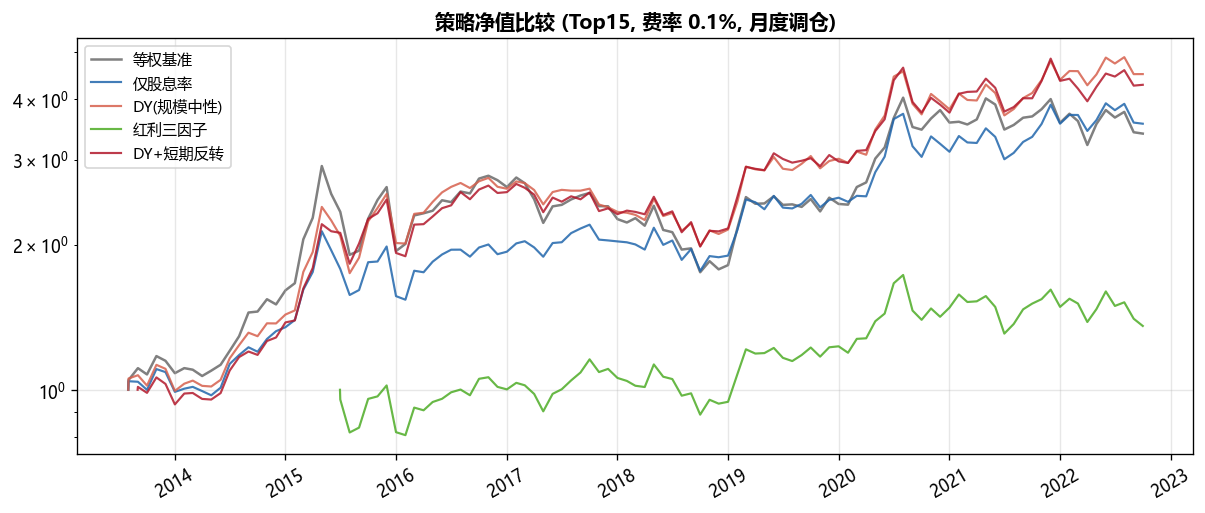

In [14]:
# Cell 14: 策略净值图
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(bm.index, bm.values, color='gray', linewidth=1.5, label='等权基准', zorder=0)
cols = ['#2166ac', '#d6604d', '#4dac26', '#b2182b']
for (label, (nv, _, _, _)), c in zip(bt_results.items(), cols):
    ax.plot(nv.index, nv.values, linewidth=1.3, color=c, label=label, alpha=0.85)
ax.set_title(f'策略净值比较 (Top{TOPN}, 费率 {FEE:.1%}, 月度调仓)', fontsize=12, fontweight='bold')
ax.set_yscale('log'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)
fig.savefig('assets/fig_06_nav.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Cell 15: 绩效指标汇总表
rows = []
for label, (nv, to, ret, met) in bt_results.items():
    r = {'策略': label}
    r.update(met)
    r['平均换手'] = f'{to.mean():.2%}'
    rows.append(r)
bm_row = {'策略': '等权基准'}
for k, v in bm_met.items():
    if k != '信息比率': bm_row[k] = v
bm_row['平均换手'] = '-'
rows.append(bm_row)
mtbl = pd.DataFrame(rows)
mtbl.to_csv('output/table_metrics.csv', index=False, encoding='utf-8-sig')
display(mtbl.style.set_caption('策略绩效指标汇总').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,策略,累计收益,年化收益,年化波动,夏普比率,最大回撤,Calmar,信息比率,月度胜率,样本月,平均换手
0,仅股息率,255.88%,14.71%,23.93%,0.49,-27.86%,0.53,-0.04,56.8%,111,9.13%
1,DY(规模中性),350.97%,17.68%,25.55%,0.57,-27.85%,0.63,0.25,55.0%,111,11.35%
2,红利三因子,35.60%,4.24%,22.68%,0.05,-24.40%,0.17,-0.11,56.8%,88,14.47%
3,DY+短期反转,328.48%,17.20%,24.80%,0.57,-25.80%,0.67,0.25,60.0%,110,40.85%
4,DY+平滑反转,95.90%,7.83%,25.47%,0.19,-39.64%,0.20,-0.47,55.1%,107,27.10%
5,精选五因子,25.82%,3.18%,22.91%,0.01,-28.34%,0.11,-0.20,56.8%,88,32.80%
6,等权基准,239.48%,14.13%,27.62%,0.40,-39.75%,0.36,nan,59.5%,111,-


### 5.2 绩效分析（续）

基础回测中，DY(规模中性) 是最干净的核心策略：年化收益和夏普均高于原始 DY 与等权基准，同时避免把小盘溢价误读为红利溢价。DY+短期反转等权合成的收益接近，但换手明显更高，实盘可用性弱于规模中性 DY。

红利稳定性、DPS 增长等质量类因子没有带来增量，主要问题是覆盖率下降和信号自身区分度不足。


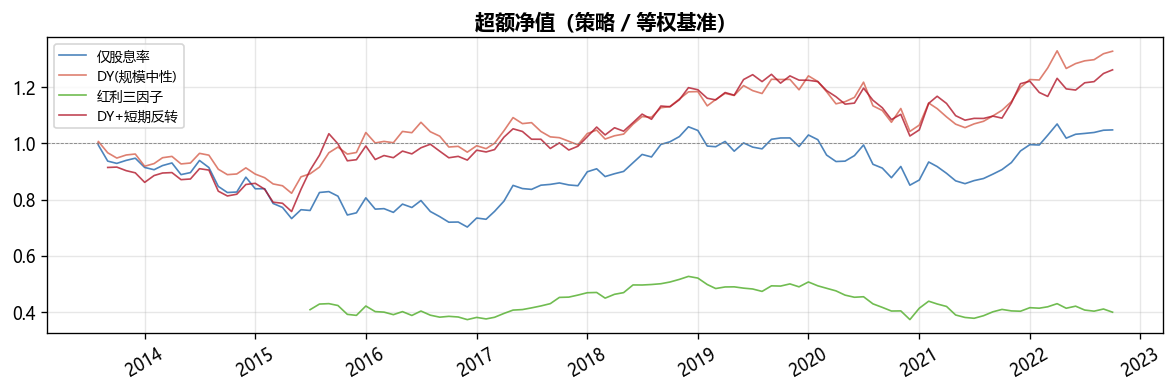

In [16]:
# Cell 16: 超额净值图
fig, ax = plt.subplots(figsize=(12, 3.2))
for (label, (nv, _, _, _)), c in zip(bt_results.items(), cols):
    ex = nv / bm.reindex(nv.index)
    ax.plot(ex.index, ex.values, linewidth=1, color=c, label=label, alpha=0.8)
ax.axhline(y=1, color='gray', lw=0.5, ls='--')
ax.set_title('超额净值（策略 / 等权基准）', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.tick_params(axis='x', rotation=30)
fig.savefig('assets/fig_07_excess.png', dpi=150, bbox_inches='tight')
plt.show()

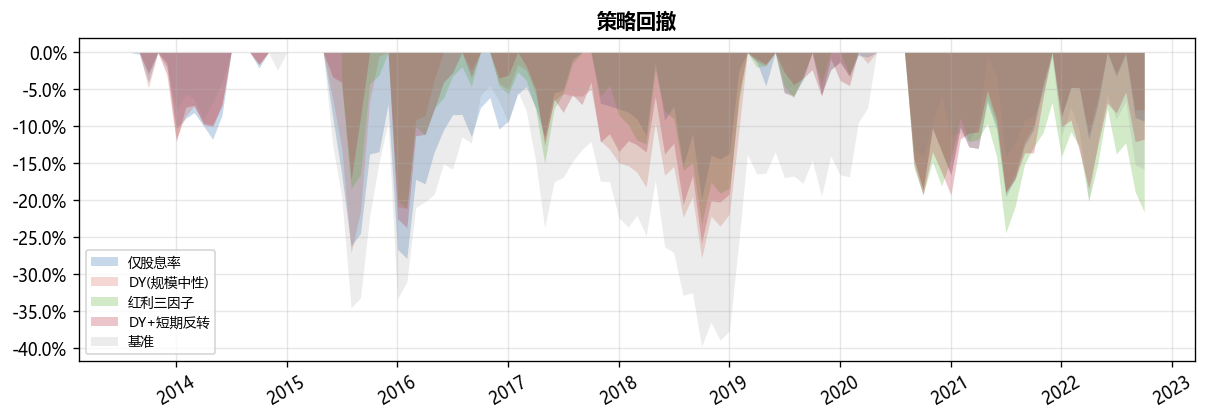

In [17]:
# Cell 17: 回撤图
fig, ax = plt.subplots(figsize=(12, 3.5))
for (label, (nv, _, _, _)), c in zip(bt_results.items(), cols):
    dd = nv / nv.cummax() - 1
    ax.fill_between(dd.index, dd.values, 0, alpha=0.25, color=c, label=label, linewidth=0)
bm_dd = bm / bm.cummax() - 1
ax.fill_between(bm_dd.index, bm_dd.values, 0, alpha=0.15, color='gray', label='基准', linewidth=0)
ax.set_title('策略回撤', fontsize=12, fontweight='bold'); ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=30)
fig.savefig('assets/fig_08_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

超额净值显示策略更像防御型风格：2017-2018、2021-2022 的弱市或分化市贡献主要超额；2015、2019-2020 的趋势牛市中弹性不足。


---
## 6. 策略增强实验

### 6.1 信号加权 vs 等权

等权 TopN 抹平了信号强度差异——排名第 1 和第 15 的股票持仓相同。信号加权在 TopN 内按信号比例分配权重，高信号股票获得更高仓位。经济逻辑：如果信号有效，信号强度应反映预期收益的差异。


In [18]:
# === 第6章: 策略增强实验 ===
# 6.1 信号加权回测
sw_results = {}
for k, label in [('DY', '仅股息率'), ('DY+Rev', 'DY+短期反转'), ('DY+RevSmooth', 'DY+平滑反转')]:
    nav, to, ret = backtest_signal_weighted(panel, k)
    sw_results[f'{label}(信号加权)'] = (nav, to, ret, compute_metrics(nav, ret, bm))

# 与等权对比
sw_rows = []
for label, (_, _, _, met_ew) in bt_results.items():
    if label in ['仅股息率', 'DY+短期反转']:
        sw_label = f'{label}(信号加权)'
        if sw_label in sw_results:
            _, _, _, met_sw = sw_results[sw_label]
            sw_rows.append({
                '方案': label, '加权方式': '等权',
                '年化收益': met_ew['年化收益'], '夏普比率': met_ew['夏普比率'],
                '最大回撤': met_ew['最大回撤'], '月度胜率': met_ew['月度胜率']
            })
            sw_rows.append({
                '方案': label, '加权方式': '信号加权',
                '年化收益': met_sw['年化收益'], '夏普比率': met_sw['夏普比率'],
                '最大回撤': met_sw['最大回撤'], '月度胜率': met_sw['月度胜率']
            })
sw_tbl = pd.DataFrame(sw_rows)
display(sw_tbl.style.set_caption('信号加权 vs 等权对比').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,方案,加权方式,年化收益,夏普比率,最大回撤,月度胜率
0,仅股息率,等权,14.71%,0.49,-27.86%,56.8%
1,仅股息率,信号加权,12.64%,0.41,-25.34%,55.0%
2,DY+短期反转,等权,17.20%,0.57,-25.80%,60.0%
3,DY+短期反转,信号加权,14.61%,0.48,-24.91%,59.1%


### 6.2 趋势过滤择时

趋势过滤用于检验"牛市放弃选股、持有基准"是否能改善全周期表现。为避免未来函数，趋势信号仅使用上一期可见的基准净值和 10 个月均线。


In [19]:
# Cell 24: 趋势过滤回测
tf_results = {}
for k, label in [('DY', '仅股息率'), ('DY+RevSmooth', 'DY+平滑反转')]:
    nav, to, ret = backtest_trend_filter(panel, k)
    tf_results[f'{label}(趋势过滤)'] = (nav, to, ret, compute_metrics(nav, ret, bm))

tf_rows = []
for label, (_, _, _, met_tf) in tf_results.items():
    base_label = label.replace('(趋势过滤)', '')
    _, _, _, met_base = bt_results[base_label]
    tf_rows.append({
        '方案': base_label, '择时': '无',
        '年化收益': met_base['年化收益'], '夏普比率': met_base['夏普比率'],
        '最大回撤': met_base['最大回撤'], '月度胜率': met_base['月度胜率']
    })
    tf_rows.append({
        '方案': base_label, '择时': '趋势过滤',
        '年化收益': met_tf['年化收益'], '夏普比率': met_tf['夏普比率'],
        '最大回撤': met_tf['最大回撤'], '月度胜率': met_tf['月度胜率']
    })
tf_tbl = pd.DataFrame(tf_rows)
display(tf_tbl.style.set_caption('趋势过滤择时对比（基准>10月均线 → 持有基准）').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,方案,择时,年化收益,夏普比率,最大回撤,月度胜率
0,仅股息率,无,14.71%,0.49,-27.86%,56.8%
1,仅股息率,趋势过滤,13.39%,0.39,-35.55%,56.8%
2,DY+平滑反转,无,7.83%,0.19,-39.64%,55.1%
3,DY+平滑反转,趋势过滤,10.12%,0.26,-42.86%,57.0%


### 6.3 再平衡缓冲带

缓冲带用于降低微小排名变化带来的交易。若新旧持仓变化低于阈值，则保留原组合。该模块仅作为交易层面的稳健性测试，不作为收益寻优手段。


,缓冲阈值,年化收益,夏普比率,最大回撤,平均换手,跳过调仓
0,无(基准),14.71%,0.49,-27.86%,9.13%,-
1,10%,14.49%,0.48,-28.48%,7.93%,61/111
2,15%,14.06%,0.46,-28.64%,6.55%,82/111
3,20%,15.28%,0.52,-26.92%,6.13%,90/111


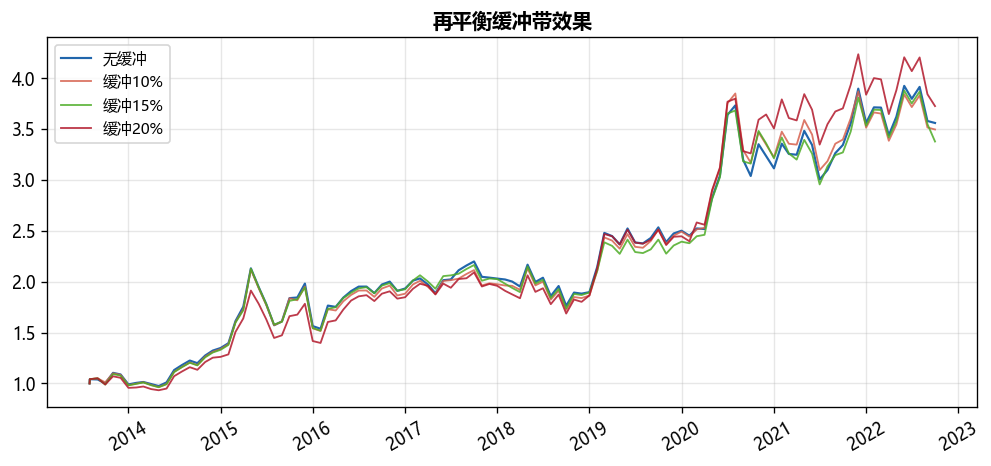

In [20]:
# Cell 18b: 缓冲带回测
def backtest_buffer(panel, signal, topn=TOPN, fee=FEE, direction=1, buffer=0.15):
    df = panel[panel[signal].notna() & panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    navs, turns, rets, valid_dates = [1.0], [], [], []
    prev = set()
    nav = 1.0
    skip_count = 0
    for m in months:
        dm = df[df['date'] == m].copy()
        if len(dm) < topn: continue
        new_top = dm.nlargest(topn, signal)['code'].tolist() if direction > 0 else dm.nsmallest(topn, signal)['code'].tolist()
        cur = set(new_top)
        if prev:
            overlap = len(prev & cur)
            churn = 1 - overlap / topn
            if churn < buffer:
                cur = prev
                skip_count += 1
            turnover = (len(prev - cur) + len(cur - prev)) / (2 * topn)
        else:
            turnover = 1.0
        ret = dm[dm['code'].isin(cur)]['price_ret'].mean()
        rets.append(ret)
        turns.append(turnover)
        nav = nav * (1 + ret - 2 * turnover * fee)
        navs.append(nav)
        valid_dates.append(m)
        prev = cur
    from pandas import Timedelta
    pre_date = valid_dates[0] - Timedelta(days=1)
    return (
        pd.Series(navs, index=[pre_date] + valid_dates),
        pd.Series(turns, index=valid_dates),
        pd.Series(rets, index=valid_dates),
        skip_count,
    )

buffer_rows = []
for buffer in [0.10, 0.15, 0.20]:
    nav_b, to_b, ret_b, skip_count = backtest_buffer(panel, 'DY', buffer=buffer)
    met_b = compute_metrics(nav_b, ret_b, bm)
    buffer_rows.append({
        '缓冲阈值': f'{buffer:.0%}',
        '年化收益': met_b['年化收益'], '夏普比率': met_b['夏普比率'],
        '最大回撤': met_b['最大回撤'], '平均换手': f'{to_b.mean():.2%}',
        '跳过调仓': f'{skip_count}/{len(ret_b)}'
    })
nav_orig, to_orig, ret_orig = backtest(panel, 'DY')
met_orig = compute_metrics(nav_orig, ret_orig, bm)
buffer_rows.insert(0, {
    '缓冲阈值': '无(基准)', '年化收益': met_orig['年化收益'],
    '夏普比率': met_orig['夏普比率'], '最大回撤': met_orig['最大回撤'],
    '平均换手': f'{to_orig.mean():.2%}', '跳过调仓': '-'
})
buf_tbl = pd.DataFrame(buffer_rows)
buf_tbl.to_csv('output/table_buffer.csv', index=False, encoding='utf-8-sig')
display(buf_tbl.style.set_caption('缓冲带敏感性').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(nav_orig.index, nav_orig.values, label='无缓冲', linewidth=1.3, color='#2166ac')
for buffer, color in zip([0.10, 0.15, 0.20], ['#d6604d', '#4dac26', '#b2182b']):
    nav_b, _, _, _ = backtest_buffer(panel, 'DY', buffer=buffer)
    ax.plot(nav_b.index, nav_b.values, label=f'缓冲{buffer:.0%}', linewidth=1.1, color=color, alpha=0.85)
ax.set_title('再平衡缓冲带效果', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)
fig.savefig('assets/fig_11_buffer.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 动态 TopN

动态 TopN 根据信号离散度调整持股数。用于检验"高分歧时分散、低分歧时集中"的组合构建逻辑；若结果等同于固定 Top30，则说明主要收益来自更高分散度，而非动态规则本身。


In [21]:
# Cell 18c: 动态 TopN
def backtest_dynamic_topn(panel, signal, fee=FEE, direction=1):
    df = panel[panel[signal].notna() & panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    navs, turns, rets, topn_hist, valid_dates = [1.0], [], [], [], []
    prev = set()
    nav = 1.0
    for m in months:
        dm = df[df['date'] == m].copy()
        if len(dm) < 30: continue
        sig_vals = dm[signal].dropna()
        if len(sig_vals) < 20: continue
        cv = sig_vals.std() / (abs(sig_vals.mean()) + 1e-12)
        topn_dynamic = int(np.clip(np.round(10 + 20 * min(cv / 1.5, 1.0)), 10, 30))
        topn_hist.append(topn_dynamic)
        top = dm.nlargest(topn_dynamic, signal)['code'].tolist() if direction > 0 else dm.nsmallest(topn_dynamic, signal)['code'].tolist()
        cur = set(top)
        ret = dm[dm['code'].isin(top)]['price_ret'].mean()
        rets.append(ret)
        turnover = 1.0 if not prev else (len(prev - cur) + len(cur - prev)) / (2 * len(cur))
        turns.append(turnover)
        nav = nav * (1 + ret - 2 * turnover * fee)
        navs.append(nav)
        valid_dates.append(m)
        prev = cur
    from pandas import Timedelta
    pre_date = valid_dates[0] - Timedelta(days=1)
    return pd.Series(navs, index=[pre_date] + valid_dates), pd.Series(turns, index=valid_dates), pd.Series(rets, index=valid_dates), topn_hist

nav_dt, to_dt, ret_dt, topn_hist = backtest_dynamic_topn(panel, 'DY')
met_dt = compute_metrics(nav_dt, ret_dt, bm)
nav_15, to_15, ret_15 = backtest(panel, 'DY', topn=15)
met_15 = compute_metrics(nav_15, ret_15, bm)
nav_30, to_30, ret_30 = backtest(panel, 'DY', topn=30)
met_30 = compute_metrics(nav_30, ret_30, bm)

dt_rows = [
    {'方案': 'Top15 固定', '年化收益': met_15['年化收益'], '夏普比率': met_15['夏普比率'], '最大回撤': met_15['最大回撤'], '平均换手': f'{to_15.mean():.2%}', 'TopN中位数': '15'},
    {'方案': 'Top30 固定', '年化收益': met_30['年化收益'], '夏普比率': met_30['夏普比率'], '最大回撤': met_30['最大回撤'], '平均换手': f'{to_30.mean():.2%}', 'TopN中位数': '30'},
    {'方案': '动态TopN(CV)', '年化收益': met_dt['年化收益'], '夏普比率': met_dt['夏普比率'], '最大回撤': met_dt['最大回撤'], '平均换手': f'{to_dt.mean():.2%}', 'TopN中位数': f'{np.median(topn_hist):.0f}'},
]
dt_tbl = pd.DataFrame(dt_rows)
dt_tbl.to_csv('output/table_dynamic_topn.csv', index=False, encoding='utf-8-sig')
display(dt_tbl.style.set_caption('动态 TopN 对比').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,方案,年化收益,夏普比率,最大回撤,平均换手,TopN中位数
0,Top15 固定,14.71%,0.49,-27.86%,9.13%,15
1,Top30 固定,17.87%,0.61,-30.67%,8.92%,30
2,动态TopN(CV),17.87%,0.61,-30.67%,8.92%,30


### 6.5 低换手增强：DY 主导 + 反转辅助

等权加入短期反转会显著抬高换手。更符合经济逻辑的处理是让 DY(规模中性) 保持主权重，只用反转信号微调排序：`0.7 × dy_neutral_z − 0.3 × rev_1m_z`。该方案在样本内改善收益和夏普，同时把换手控制在等权反转方案之下。


In [22]:
# Cell 18d: 低换手增强回测（DY主导+反转辅助）
# 构建 monthly composite: 0.7*dy_neutral_z + 0.3*(-rev_1m_z)
from scipy.stats import zscore
df_c = panel[panel['dy_neutral'].notna() & panel['rev_1m'].notna() & panel['price_ret'].notna()].copy()
months_c = sorted(df_c['date'].unique())
composites = {}
for m in months_c:
    dm = df_c[df_c['date'] == m].copy()
    dy_z = (dm['dy_neutral'] - dm['dy_neutral'].mean()) / (dm['dy_neutral'].std() + 1e-10)
    rev_z = (dm['rev_1m'] - dm['rev_1m'].mean()) / (dm['rev_1m'].std() + 1e-10)
    composites[m] = 0.7 * dy_z - 0.3 * rev_z  # rev_1m direction is negative

# Backtest function
def backtest_composite(panel, composite_dict, topn=TOPN, fee=FEE):
    df = panel[panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    navs, turns, rets_list, valid_dates = [1.0], [], [], []
    prev_weights = {}
    nav = 1.0
    for m in months:
        if m not in composite_dict:
            continue
        dm = df[df['date'] == m].copy()
        dm['composite'] = composite_dict[m]
        dm = dm.dropna(subset=['composite'])
        if len(dm) < topn:
            continue
        dm = dm.nlargest(topn, 'composite')
        cur_weights = {c: 1.0/topn for c in dm['code'].tolist()}
        ret = dm['price_ret'].mean()
        rets_list.append(ret)
        if prev_weights:
            common = set(prev_weights) & set(cur_weights)
            turnover = 0.5 * sum(
                abs(prev_weights.get(c, 0) - cur_weights.get(c, 0))
                for c in set(list(prev_weights) + list(cur_weights))
            )
        else:
            turnover = 1.0
        turns.append(turnover)
        cost = 2 * turnover * fee
        nav = nav * (1 + ret - cost)
        navs.append(nav)
        valid_dates.append(m)
        prev_weights = cur_weights
    from pandas import Timedelta
    pre_date = valid_dates[0] - Timedelta(days=1)
    idx_all = [pre_date] + valid_dates
    return pd.Series(navs, index=idx_all), pd.Series(turns, index=valid_dates), pd.Series(rets_list, index=valid_dates)

nv_mb, to_mb, ret_mb = backtest_composite(panel, composites)
met_mb = compute_metrics(nv_mb, ret_mb, bm)

# 对比原策略
mb_rows = [
    {'方案': 'DY(规模中性)', '年化收益': bt_results['DY(规模中性)'][3]['年化收益'],
     '夏普比率': bt_results['DY(规模中性)'][3]['夏普比率'],
     '最大回撤': bt_results['DY(规模中性)'][3]['最大回撤'],
     '月度胜率': bt_results['DY(规模中性)'][3]['月度胜率'],
     '平均换手': f"{bt_results['DY(规模中性)'][1].mean()*100:.1f}%"},
    {'方案': 'DY+短期反转(等权)', '年化收益': bt_results['DY+短期反转'][3]['年化收益'],
     '夏普比率': bt_results['DY+短期反转'][3]['夏普比率'],
     '最大回撤': bt_results['DY+短期反转'][3]['最大回撤'],
     '月度胜率': bt_results['DY+短期反转'][3]['月度胜率'],
     '平均换手': f"{bt_results['DY+短期反转'][1].mean()*100:.1f}%"},
    {'方案': '0.7×DY_neut+0.3×Rev', '年化收益': met_mb['年化收益'],
     '夏普比率': met_mb['夏普比率'],
     '最大回撤': met_mb['最大回撤'],
     '月度胜率': met_mb['月度胜率'],
     '平均换手': f"{to_mb.mean()*100:.1f}%"},
]
mb_tbl = pd.DataFrame(mb_rows)
mb_tbl.to_csv('output/table_enhanced_core.csv', index=False, encoding='utf-8-sig')
display(mb_tbl.style.set_caption('低换手增强：DY主导(70%)+反转辅助(30%) vs 等权合成').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))


,方案,年化收益,夏普比率,最大回撤,月度胜率,平均换手
0,DY(规模中性),17.68%,0.57,-27.85%,55.0%,11.4%
1,DY+短期反转(等权),17.20%,0.57,-25.80%,60.0%,40.8%
2,0.7×DY_neut+0.3×Rev,19.45%,0.64,-27.33%,60.0%,27.4%


### 6.6 随机组合基准

随机组合基准回答一个简单问题：Top15 策略是否只是碰巧选中了少数牛股。做法是每月从可交易池随机抽取 15 只股票，重复 1000 次，比较实际策略在随机分布中的位置。


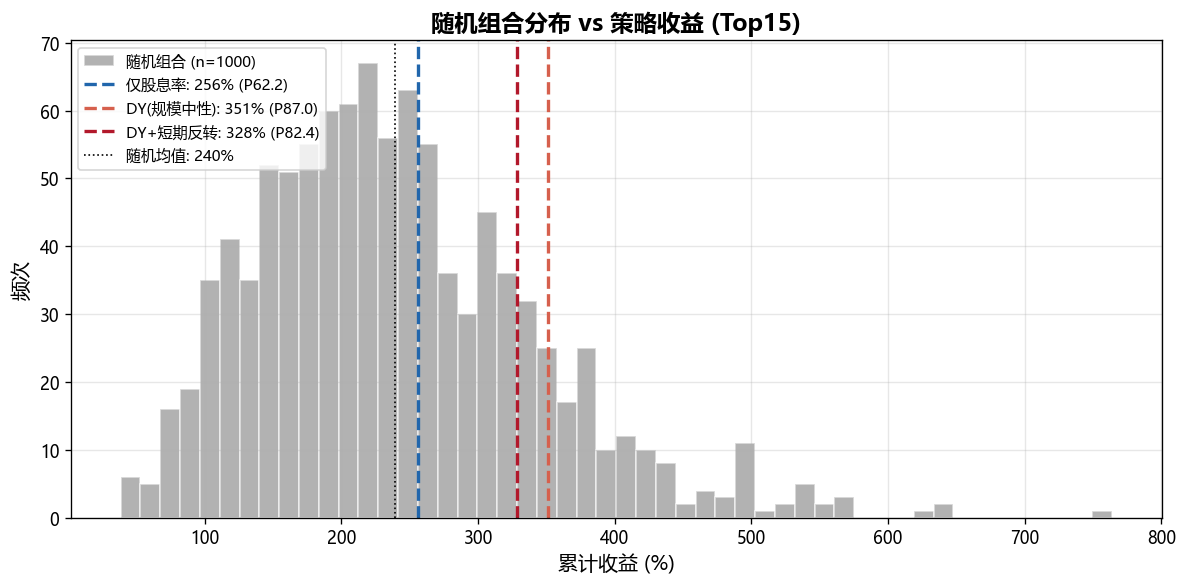

,对象,累计收益,随机分位,Z值
0,随机组合中位数,226%,50.0,0.00
1,随机组合均值,240%,-,-
2,仅股息率,256%,P62.2,0.16
3,DY(规模中性),351%,P87.0,1.09
4,DY+短期反转,328%,P82.4,0.87


In [23]:
# Cell 18e: 随机组合基准
np.random.seed(42)

def run_random_benchmark(panel, topn=15, n_iter=1000):
    df = panel[panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    monthly_dfs = {m: df[df['date'] == m] for m in months}
    all_navs = []
    for _ in range(n_iter):
        nav = 1.0
        for m in months:
            dm = monthly_dfs[m]
            if len(dm) < topn:
                continue
            chosen = dm.sample(n=topn, replace=False)
            nav *= (1 + chosen['price_ret'].mean())
        all_navs.append(nav)
    return pd.Series(all_navs)

rand_result = run_random_benchmark(panel, topn=15, n_iter=1000)
rand_cumrets = rand_result - 1

strat_cumrets = {}
for label in ['仅股息率', 'DY(规模中性)', 'DY+短期反转']:
    nv = bt_results[label][0]
    strat_cumrets[label] = nv.iloc[-1] - 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rand_cumrets * 100, bins=50, alpha=0.6, color='gray', edgecolor='white', label='随机组合 (n=1000)')
colors = ['#2166ac', '#d6604d', '#b2182b']
for i, (label, cret) in enumerate(strat_cumrets.items()):
    pct = (rand_cumrets < cret).mean() * 100
    ax.axvline(cret * 100, color=colors[i], linewidth=2, linestyle='--',
               label=f'{label}: {cret*100:.0f}% (P{pct:.1f})')
ax.axvline(rand_cumrets.mean() * 100, color='black', linewidth=1, linestyle=':',
           label=f'随机均值: {rand_cumrets.mean()*100:.0f}%')
ax.set_xlabel('累计收益 (%)', fontsize=12)
ax.set_ylabel('频次', fontsize=12)
ax.set_title('随机组合分布 vs 策略收益 (Top15)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('assets/fig_13_random_benchmark.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

rand_rows = [
    {'对象': '随机组合中位数', '累计收益': f'{rand_cumrets.median():.0%}', '随机分位': '50.0', 'Z值': '0.00'},
    {'对象': '随机组合均值', '累计收益': f'{rand_cumrets.mean():.0%}', '随机分位': '-', 'Z值': '-'},
]
for label, cret in strat_cumrets.items():
    pct = (rand_cumrets < cret).mean() * 100
    z = (cret - rand_cumrets.mean()) / rand_cumrets.std()
    rand_rows.append({'对象': label, '累计收益': f'{cret:.0%}', '随机分位': f'P{pct:.1f}', 'Z值': f'{z:.2f}'})
rand_tbl = pd.DataFrame(rand_rows)
rand_tbl.to_csv('output/table_random_benchmark.csv', index=False, encoding='utf-8-sig')
display(rand_tbl.style.set_caption('随机组合基准检验').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

---
## 7. 稳健性检验

本节检验策略对调仓频率、TopN、费率的敏感性，并通过滚动验证、多空验证、年度分解检验策略稳健性。


In [24]:
# Cell 18: 调仓频率 + TopN + 费率敏感性
MAIN = 'DY'
main_label = combos[MAIN][1]

# === 6.1 调仓频率 ===
nav_m, to_m, ret_m = backtest(panel, MAIN)
met_m = compute_metrics(nav_m, ret_m, bm)

def backtest_quarterly(panel, signal, topn=TOPN, fee=FEE, direction=1):
    df = panel[panel[signal].notna() & panel['price_ret'].notna()].copy()
    all_months = sorted(df['date'].unique())
    rebalance_months = [m for m in all_months if m.month in {1, 4, 7, 10}]
    nav = 1.0
    navs, turns, rets = [1.0], [], []
    holdings = None
    prev_top = []
    for i, rb_m in enumerate(rebalance_months):
        dm = df[df['date'] == rb_m].copy()
        if len(dm) < topn: continue
        if direction > 0:
            top = dm.nlargest(topn, signal)['code'].tolist()
        else:
            top = dm.nsmallest(topn, signal)['code'].tolist()
        holdings = set(top)
        if i > 0:
            prev_set = set(prev_top)
            turnover = (len(prev_set - holdings) + len(holdings - prev_set)) / (2 * topn)
        else:
            turnover = 1.0
        hold_start = all_months.index(rb_m)
        hold_end = min(hold_start + 3, len(all_months))
        for j, hm in enumerate(all_months[hold_start:hold_end]):
            dm_h = df[df['date'] == hm]
            ret = dm_h[dm_h['code'].isin(holdings)]['price_ret'].mean()
            if np.isnan(ret): continue
            rets.append(ret)
            cost = 2 * turnover * fee if j == 0 else 0.0
            if j == 0:
                turns.append(turnover)
            nav = nav * (1 + ret - cost)
            navs.append(nav)
        prev_top = top
    ret_dates = []
    for rb_m in rebalance_months:
        hs = all_months.index(rb_m)
        he = min(hs + 3, len(all_months))
        ret_dates.extend(all_months[hs:he])
    ret_dates = ret_dates[:len(rets)]
    from pandas import Timedelta
    pre_date = ret_dates[0] - Timedelta(days=1)
    date_idx = [pre_date] + ret_dates
    turn_dates = rebalance_months[:len(turns)]
    return pd.Series(navs, index=date_idx), pd.Series(turns, index=turn_dates), pd.Series(rets, index=ret_dates)

nav_q, to_q, ret_q = backtest_quarterly(panel, MAIN)
bm_q = bm.reindex(nav_q.index).dropna()
met_q = compute_metrics(nav_q, ret_q, bm_q)

freq = pd.DataFrame({
    '调仓频率': ['月度', '季度'],
    '年化收益': [met_m['年化收益'], met_q.get('年化收益', '-')],
    '夏普比率': [met_m['夏普比率'], met_q.get('夏普比率', '-')],
    '最大回撤': [met_m['最大回撤'], met_q.get('最大回撤', '-')],
    '平均换手': [f'{to_m.mean():.2%}', f'{to_q.mean():.2%}']
})
freq.to_csv('output/table_freq.csv', index=False, encoding='utf-8-sig')
display(freq.style.set_caption('调仓频率敏感性').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

topn_rows = []
for n in [10, 15, 20, 30]:
    nv, t, r = backtest(panel, MAIN, topn=n)
    m = compute_metrics(nv, r, bm)
    topn_rows.append({'TopN': n, '年化收益': m['年化收益'], '夏普比率': m['夏普比率'],
                      '最大回撤': m['最大回撤'], '平均换手': f'{t.mean():.2%}'})
topn_tbl = pd.DataFrame(topn_rows)
topn_tbl.to_csv('output/table_topn.csv', index=False, encoding='utf-8-sig')
display(topn_tbl.style.set_caption('TopN 敏感性').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

fee_rows = []
for fee in [0, 0.001, 0.002, 0.003]:
    nv, t, r = backtest(panel, MAIN, fee=fee)
    m = compute_metrics(nv, r, bm)
    fee_rows.append({'费率': f'{fee:.3f}', '年化收益': m['年化收益'],
                     '夏普比率': m['夏普比率'], '最大回撤': m['最大回撤']})
fee_tbl = pd.DataFrame(fee_rows)
fee_tbl.to_csv('output/table_fee.csv', index=False, encoding='utf-8-sig')
display(fee_tbl.style.set_caption('费率敏感性').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,调仓频率,年化收益,夏普比率,最大回撤,平均换手
0,月度,14.71%,0.49,-27.86%,9.13%
1,季度,14.20%,0.46,-30.04%,18.74%


,TopN,年化收益,夏普比率,最大回撤,平均换手
0,10,11.21%,0.32,-29.76%,9.46%
1,15,14.71%,0.49,-27.86%,9.13%
2,20,16.44%,0.56,-26.58%,9.82%
3,30,17.87%,0.61,-30.67%,8.92%


,费率,年化收益,夏普比率,最大回撤
0,0.000,14.96%,0.50,-27.73%
1,0.001,14.71%,0.49,-27.86%
2,0.002,14.46%,0.48,-27.99%
3,0.003,14.21%,0.47,-28.12%


### 7.1 调仓频率

季度调仓表现接近月度调仓，但并未带来更低换手。策略本身对调仓频率不敏感，说明 DY 信号持有期较长。

### 7.2 TopN 敏感性

TopN 从 10 增至 30 后，收益和夏普上升，说明 DY 信号在较宽范围内有区分度，也说明适度分散能降低个股噪声。

### 7.3 费率敏感性

费率敏感性较低，主要来自主策略换手不高。增强方案仍需关注冲击成本和容量约束。


,年度,策略收益,基准收益,超额收益
0,2014,21.55%,30.88%,-9.33%
1,2015,49.79%,75.03%,-25.24%
2,2016,-3.61%,3.34%,-6.95%
3,2017,6.79%,-11.70%,18.49%
4,2018,-7.71%,-25.99%,18.28%
5,2019,31.42%,40.78%,-9.36%
6,2020,30.74%,51.83%,-21.10%
7,2021,20.49%,5.42%,15.07%
8,2022,-8.66%,-15.19%,6.53%


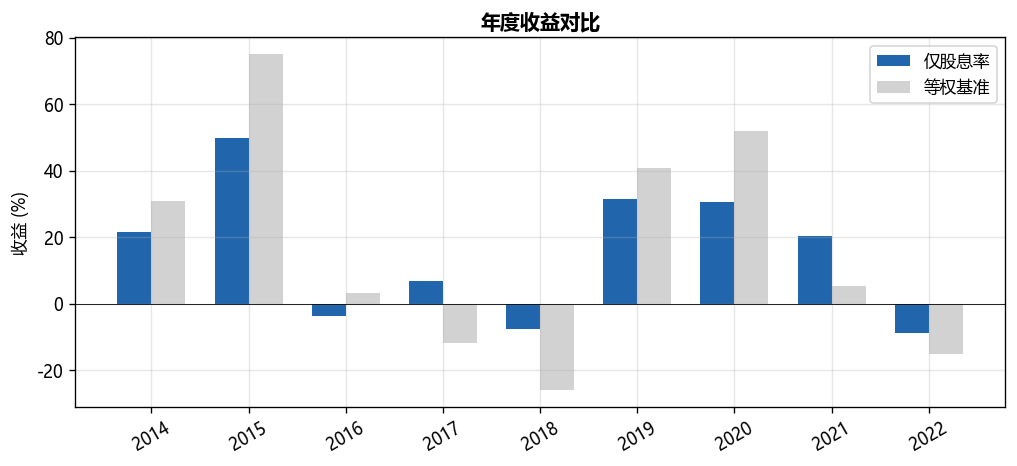

In [25]:
# Cell 19: 年度表现
main_nav, _, _ = backtest(panel, MAIN)
yr = main_nav.resample('YE').last().pct_change().dropna()
yr_bm = bm.resample('YE').last().pct_change().dropna()
yr_ex = yr - yr_bm.reindex(yr.index)

annual = pd.DataFrame({
    '年度': [str(y.year) for y in yr.index],
    '策略收益': [f'{v:.2%}' for v in yr.values],
    '基准收益': [f'{v:.2%}' for v in yr_bm.reindex(yr.index).values],
    '超额收益': [f'{v:.2%}' for v in yr_ex.values],
})
annual.to_csv('output/table_annual.csv', index=False, encoding='utf-8-sig')
display(annual.style.set_caption('年度收益对比').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(yr)); w = 0.35
ax.bar(x - w/2, yr.values * 100, w, label=main_label, color='#2166ac')
ax.bar(x + w/2, yr_bm.reindex(yr.index).values * 100, w, label='等权基准', color='gray', alpha=0.35)
ax.set_xticks(x); ax.set_xticklabels([str(y.year) for y in yr.index], rotation=30)
ax.set_ylabel('收益 (%)'); ax.set_title('年度收益对比', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.axhline(0, color='black', lw=0.5)
fig.savefig('assets/fig_09_annual.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 年度表现

年度结果用于识别策略风格：弱市和结构分化年份更容易取得正超额，趋势牛市中容易跑输。这一特征决定了策略更适合作为消费行业中的防御型子策略，而非进攻型收益来源。


In [26]:
# Cell 20: 滚动验证（3 年训练 + 1 年验证）
all_mo = sorted(panel['date'].unique())
roll_rows = []
for si in range(0, len(all_mo) - 36 - 12 + 1, 12):
    train_d = all_mo[si:si+36]
    test_d = all_mo[si+36:si+48]
    train_m = panel['date'].isin(train_d)
    test_m = panel['date'].isin(test_d)
    good = []
    for f in ALL_FACTORS:
        ics = []
        for md in train_d:
            sm_data = panel[(panel['date'] == md) & panel[f].notna() & panel['price_ret'].notna()]
            if len(sm_data) < 10: continue
            ic = np.corrcoef(sm_data[f].values * FACTOR_DIR[f], sm_data['price_ret'].values)[0, 1]
            if not np.isnan(ic): ics.append(ic)
        if ics and np.mean(ics) > 0:
            good.append(f)
    if not good:
        good = ['dy']
    pc = panel.copy()
    pc['roll_sig'] = build_composite(pc, good, FACTOR_DIR)
    nv, t, r = backtest(pc[test_m], 'roll_sig')
    bm_t = bm.reindex(nv.index).dropna()
    r1 = nv.iloc[-1] - 1
    r2 = bm_t.iloc[-1] / bm_t.iloc[0] - 1
    roll_rows.append({
        '验证期': f'{test_d[0].date()}'[:7],
        '所选因子': '+'.join([FACTOR_LABEL[f] for f in good]),
        '策略': f'{r1:.2%}', '基准': f'{r2:.2%}',
        '超额': f'{r1 - r2:.2%}'
    })
roll_tbl = pd.DataFrame(roll_rows)
roll_tbl.to_csv('output/table_rolling.csv', index=False, encoding='utf-8-sig')
display(roll_tbl.style.set_caption('滚动验证（3 年训练 + 1 年验证）').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,验证期,所选因子,策略,基准,超额
0,2016-08,DY(规模中性)+DY同比变化+ln(市值)+短期反转+平滑反转+长期反转,-0.41%,-6.16%,5.75%
1,2017-08,股息率 DY+DY(规模中性)+红利稳定性+DY同比变化+ln(市值)+短期反转+平滑反转+长期反转+低波动,-12.48%,-14.46%,1.98%
2,2018-08,股息率 DY+DY(规模中性)+红利稳定性+DPS增长+DY同比变化+短期反转+中期动量+低波动,25.27%,23.76%,1.51%
3,2019-08,股息率 DY+DY(规模中性)+红利稳定性+DPS增长+短期反转+中期动量+低波动,51.80%,51.01%,0.79%
4,2020-08,股息率 DY+DY(规模中性)+红利稳定性+DPS增长+短期反转+中期动量+低波动,-15.88%,-14.12%,-1.76%
5,2021-08,股息率 DY+DY(规模中性)+红利稳定性+短期反转+平滑反转+中期动量+低波动,25.40%,3.60%,21.80%


### 7.5 滚动验证

滚动验证用过去 3 年选择因子，再观察后 1 年表现。其目的不是继续寻优，而是检查因子选择是否稳定。结果显示 DY 经常被选入，但纯数据驱动的自适应因子权重在样本有限时并不可靠。


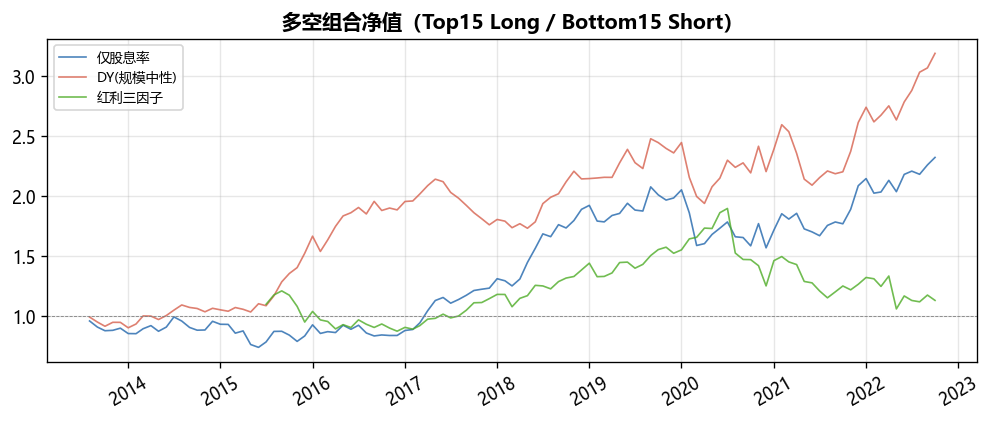

In [27]:
# Cell 21: 多空验证
ls_navs = {}
for k, (fs, label) in list(combos.items())[:3]:
    df_ls = panel[panel[k].notna() & panel['price_ret'].notna()]
    months = sorted(df_ls['date'].unique())
    ls_rets = []
    for m in months:
        dm = df_ls[df_ls['date'] == m]
        if len(dm) < TOPN * 2: continue
        lc = dm.nlargest(TOPN, k)['code'].tolist()
        sc = dm.nsmallest(TOPN, k)['code'].tolist()
        ls_rets.append(dm[dm['code'].isin(lc)]['price_ret'].mean() - dm[dm['code'].isin(sc)]['price_ret'].mean())
    if ls_rets:
        ls_navs[label] = (1 + pd.Series(ls_rets, index=months[-len(ls_rets):])).cumprod()

fig, ax = plt.subplots(figsize=(10, 3.5))
for (label, lsn), c in zip(ls_navs.items(), cols):
    ax.plot(lsn.index, lsn.values, linewidth=1, color=c, label=label, alpha=0.8)
ax.axhline(1, color='gray', lw=0.5, ls='--'); ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_title(f'多空组合净值（Top{TOPN} Long / Bottom{TOPN} Short）', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
fig.savefig('assets/fig_10_ls_nav.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 多空验证

多空组合用于剥离市场方向，观察信号本身是否能区分股票。DY 与短期反转的多空净值上行，红利三因子较弱。


---
## 8. 统计验证

### 8.1 Bootstrap 夏普比率显著性检验

111 个月样本下，策略夏普 0.57 是否显著优于基准的 0.40？用 Bootstrap 重采样（10000 次）构造夏普差异的经验分布，计算单侧 p 值。


,策略,夏普差异,95% CI,p值(H0:≤0),显著性
0,仅股息率,0.0691,"[-0.2213, 0.3525]",0.3191,
1,DY(规模中性),0.1503,"[-0.1011, 0.3859]",0.1192,
2,红利三因子,0.0112,"[-0.3104, 0.3266]",0.4710,
3,DY+短期反转,0.1908,"[-0.0745, 0.4835]",0.0837,*
4,DY+平滑反转,-0.1291,"[-0.4072, 0.1335]",0.8367,
5,精选五因子,-0.0135,"[-0.3774, 0.3422]",0.5285,


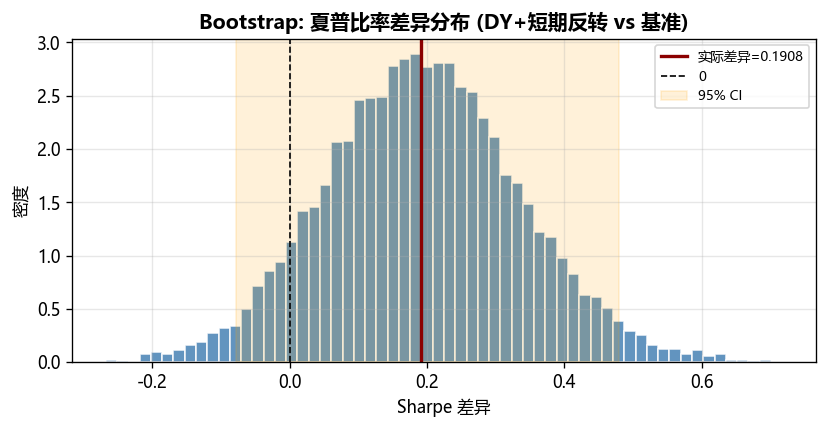

In [28]:
# === 第8章: 统计验证 ===
# Cell 25: Bootstrap Sharpe difference test
def bootstrap_sharpe_test(strat_rets, bm_rets, n_boot=10000, rf=0.03):
    sr = np.array(strat_rets).flatten()
    br = np.array(bm_rets).flatten()
    n = len(sr)
    ann_sr = (np.mean(sr)*12 - rf) / (np.std(sr)*np.sqrt(12))
    ann_br = (np.mean(br)*12 - rf) / (np.std(br)*np.sqrt(12))
    actual_diff = ann_sr - ann_br

    diffs = []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        sr_b = sr[idx]
        br_b = br[idx]
        s = (np.mean(sr_b)*12 - rf) / (np.std(sr_b)*np.sqrt(12))
        b = (np.mean(br_b)*12 - rf) / (np.std(br_b)*np.sqrt(12))
        diffs.append(s - b)
    diffs = np.array(diffs)
    p_val = np.mean(diffs <= 0)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    return actual_diff, p_val, ci_lo, ci_hi, diffs

boot_results = []
for label, (_, _, rets, _) in bt_results.items():
    common = rets.index.intersection(bm_rets.index)
    sr = rets.loc[common].values
    br = bm_rets.loc[common].values
    diff, pv, ci_lo, ci_hi, _ = bootstrap_sharpe_test(sr, br)
    sig = '***' if pv < 0.01 else ('**' if pv < 0.05 else ('*' if pv < 0.10 else ''))
    boot_results.append({
        '策略': label,
        '夏普差异': f'{diff:.4f}',
        '95% CI': f'[{ci_lo:.4f}, {ci_hi:.4f}]',
        'p值(H0:≤0)': f'{pv:.4f}',
        '显著性': sig
    })
boot_tbl = pd.DataFrame(boot_results)
boot_tbl.to_csv('output/table_bootstrap.csv', index=False, encoding='utf-8-sig')
display(boot_tbl.style.set_caption('Bootstrap 夏普差异检验 (10,000 次重采样)').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

_, _, rets_dyrev, _ = bt_results['DY+短期反转']
common = rets_dyrev.index.intersection(bm_rets.index)
sr_dr = rets_dyrev.loc[common].values
br_dr = bm_rets.loc[common].values
diff, pv, ci_lo, ci_hi, diffs = bootstrap_sharpe_test(sr_dr, br_dr)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(diffs, bins=60, color='steelblue', edgecolor='white', alpha=0.85, density=True)
ax.axvline(diff, color='darkred', lw=2, label=f'实际差异={diff:.4f}')
ax.axvline(0, color='black', lw=1, ls='--', label='0')
ax.axvspan(ci_lo, ci_hi, color='orange', alpha=0.15, label='95% CI')
ax.set_title('Bootstrap: 夏普比率差异分布 (DY+短期反转 vs 基准)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sharpe 差异')
ax.set_ylabel('密度')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.savefig('assets/fig_12_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Fama-MacBeth 截面回归

Fama-MacBeth 回归用于补充分组回测和 IC 统计。本文更关注方向和边际贡献，而不是把有限样本下的 t 值过度解释为稳定定价结论。


In [29]:
from statsmodels.api import add_constant, OLS
# Cell 26: Fama-MacBeth regression
def fama_macbeth(panel, factor, n_min=15):
    # 单因子 Fama-MacBeth 回归：每月 price_ret ~ factor。
    df = panel[panel[factor].notna() & panel['price_ret'].notna()].copy()
    months = sorted(df['date'].unique())
    premiums = []
    for m in months:
        dm = df[df['date'] == m].copy()
        dm['f_aligned'] = dm[factor] * FACTOR_DIR.get(factor, 1)
        dm = dm.dropna(subset=['f_aligned', 'price_ret'])
        if len(dm) < n_min:
            continue
        X = add_constant(dm['f_aligned'].values)
        y = dm['price_ret'].values
        try:
            premiums.append(OLS(y, X).fit().params[1])
        except Exception:
            continue
    prem_arr = np.array(premiums)
    if len(prem_arr) < 12:
        return {'因子': FACTOR_LABEL.get(factor, factor), '月均溢价(bp)': np.nan, 'FM_t值': np.nan, '溢价>0占比': np.nan, 'N': len(prem_arr)}
    fm_t = np.mean(prem_arr) / (np.std(prem_arr) / np.sqrt(len(prem_arr)))
    return {
        '因子': FACTOR_LABEL.get(factor, factor),
        '月均溢价(bp)': f'{np.mean(prem_arr)*10000:.1f}',
        'FM_t值': f'{fm_t:.2f}',
        '溢价>0占比': f'{np.mean(prem_arr > 0):.1%}',
        'N': len(prem_arr)
    }

fm_core = ['dy', 'dy_neutral', 'rev_1m', 'rev_smooth', 'ln_cap']
fm_tbl = pd.DataFrame([fama_macbeth(panel, f) for f in fm_core])
fm_tbl.to_csv('output/table_fm_single.csv', index=False, encoding='utf-8-sig')
display(fm_tbl.style.set_caption('Fama-MacBeth 单因子回归结果（被解释变量：price_ret）').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

def _fm_t(series):
    return series.mean() / (series.std() / np.sqrt(len(series))) if len(series) > 12 and series.std() > 0 else np.nan

def _fmt_bp(x):
    return f'{x*10000:.1f}'

def _fmt_t(x):
    return f'{x:.2f}' if pd.notna(x) else '-'

# FM multivariate: dy + rev_1m
df_fm = panel[panel['dy'].notna() & panel['rev_1m'].notna() & panel['price_ret'].notna()].copy()
mv_prem = []
for m in sorted(df_fm['date'].unique()):
    dm = df_fm[df_fm['date'] == m].copy()
    dm['dy_a'] = dm['dy'] * FACTOR_DIR['dy']
    dm['rev_a'] = dm['rev_1m'] * FACTOR_DIR['rev_1m']
    dm = dm.dropna(subset=['dy_a', 'rev_a', 'price_ret'])
    if len(dm) < 15:
        continue
    try:
        model = OLS(dm['price_ret'].values, add_constant(dm[['dy_a', 'rev_a']].values)).fit()
        mv_prem.append({'模型': 'DY + Rev', 'dy_prem': model.params[1], 'rev_prem': model.params[2]})
    except Exception:
        continue
mv_df = pd.DataFrame(mv_prem)

# FM multivariate: dy + ln_cap + rev_1m
df_fm2 = panel[panel['dy'].notna() & panel['ln_cap'].notna() & panel['rev_1m'].notna() & panel['price_ret'].notna()].copy()
mv_prem2 = []
for m in sorted(df_fm2['date'].unique()):
    dm = df_fm2[df_fm2['date'] == m].copy()
    dm['dy_a'] = dm['dy'] * FACTOR_DIR['dy']
    dm['rev_a'] = dm['rev_1m'] * FACTOR_DIR['rev_1m']
    dm = dm.dropna(subset=['dy_a', 'ln_cap', 'rev_a', 'price_ret'])
    if len(dm) < 15:
        continue
    try:
        model = OLS(dm['price_ret'].values, add_constant(dm[['dy_a', 'ln_cap', 'rev_a']].values)).fit()
        mv_prem2.append({'模型': 'DY + Size + Rev', 'dy_prem': model.params[1], 'cap_prem': model.params[2], 'rev_prem': model.params[3]})
    except Exception:
        continue
mv_df2 = pd.DataFrame(mv_prem2)

fm_multi_rows = []
if len(mv_df) > 12:
    fm_multi_rows.append({'模型': 'DY + Rev', '变量': 'DY', '月均溢价(bp)': _fmt_bp(mv_df['dy_prem'].mean()), 'FM_t值': _fmt_t(_fm_t(mv_df['dy_prem'])), 'N': len(mv_df)})
    fm_multi_rows.append({'模型': 'DY + Rev', '变量': 'Rev', '月均溢价(bp)': _fmt_bp(mv_df['rev_prem'].mean()), 'FM_t值': _fmt_t(_fm_t(mv_df['rev_prem'])), 'N': len(mv_df)})
if len(mv_df2) > 12:
    fm_multi_rows.append({'模型': 'DY + Size + Rev', '变量': 'DY', '月均溢价(bp)': _fmt_bp(mv_df2['dy_prem'].mean()), 'FM_t值': _fmt_t(_fm_t(mv_df2['dy_prem'])), 'N': len(mv_df2)})
    fm_multi_rows.append({'模型': 'DY + Size + Rev', '变量': 'ln_cap', '月均溢价(bp)': _fmt_bp(mv_df2['cap_prem'].mean()), 'FM_t值': _fmt_t(_fm_t(mv_df2['cap_prem'])), 'N': len(mv_df2)})
    fm_multi_rows.append({'模型': 'DY + Size + Rev', '变量': 'Rev', '月均溢价(bp)': _fmt_bp(mv_df2['rev_prem'].mean()), 'FM_t值': _fmt_t(_fm_t(mv_df2['rev_prem'])), 'N': len(mv_df2)})
fm_multi_tbl = pd.DataFrame(fm_multi_rows)
fm_multi_tbl.to_csv('output/table_fm_multi.csv', index=False, encoding='utf-8-sig')
display(fm_multi_tbl.style.set_caption('Fama-MacBeth 多因子回归结果').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

,因子,月均溢价(bp),FM_t值,溢价>0占比,N
0,股息率 DY,8.6,0.73,55.9%,111
1,DY(规模中性),22.7,2.47,58.6%,111
2,短期反转,444.8,2.55,62.7%,110
3,平滑反转,117.4,0.41,53.3%,107
4,ln(市值),40.8,1.75,56.8%,111


,模型,变量,月均溢价(bp),FM_t值,N
0,DY + Rev,DY,2.0,0.17,110
1,DY + Rev,Rev,428.5,2.15,110
2,DY + Size + Rev,DY,14.4,1.60,110
3,DY + Size + Rev,ln_cap,-29.1,-1.20,110
4,DY + Size + Rev,Rev,478.1,2.40,110


### 8.3 子期稳健性检验

将样本拆为 2013-2017 与 2018-2022，观察因子是否只在单一市场阶段有效。


In [30]:
# Cell 27: 子期分析
def sub_period_analysis(panel, split_date='2018-01-01'):
    split_dt = pd.Timestamp(split_date)
    periods = {'前期 (2013-2017)': panel['date'] < split_dt, '后期 (2018-2022)': panel['date'] >= split_dt}
    sub_results = []
    for label, mask in periods.items():
        sub_panel = panel[mask].copy()
        for f in ['dy', 'dy_neutral', 'rev_1m', 'rev_smooth']:
            res = single_factor_test(sub_panel, f, FACTOR_DIR[f])
            res['时期'] = label
            sub_results.append(res)

    sub_tbl = pd.DataFrame(sub_results)
    disp_sub = sub_tbl[['时期', '因子', 'G1月均收益', '多空差值', '多空t值', 'IC Mean', 'RankIC Mean', 'IC>0占比']].copy()
    for col in ['G1月均收益', '多空差值']:
        disp_sub[col] = disp_sub[col].apply(lambda x: f'{x:.2%}')
    disp_sub['多空t值'] = disp_sub['多空t值'].apply(lambda x: f'{x:.2f}')
    disp_sub['IC Mean'] = disp_sub['IC Mean'].apply(lambda x: f'{x:.4f}')
    disp_sub['RankIC Mean'] = disp_sub['RankIC Mean'].apply(lambda x: f'{x:.4f}')
    disp_sub['IC>0占比'] = disp_sub['IC>0占比'].apply(lambda x: f'{x:.1%}')
    disp_sub.to_csv('output/table_subperiod_factor.csv', index=False, encoding='utf-8-sig')

    display(disp_sub.style.set_caption('子期因子有效性对比').set_table_styles(
        [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
    ))

    sub_bt_rows = []
    for label, mask in periods.items():
        sub_panel = panel[mask].copy()
        sub_bm = benchmark_nav(sub_panel)
        nav, to, ret = backtest(sub_panel, 'DY')
        met = compute_metrics(nav, ret, sub_bm)
        sub_bt_rows.append({
            '时期': label, '年化收益': met['年化收益'], '夏普比率': met['夏普比率'],
            '最大回撤': met['最大回撤'], '样本月': met['样本月']
        })
    sub_bt_rows.append({
        '时期': '全期 (2013-2022)', '年化收益': met_orig['年化收益'],
        '夏普比率': met_orig['夏普比率'], '最大回撤': met_orig['最大回撤'],
        '样本月': met_orig['样本月']
    })
    sub_bt_tbl = pd.DataFrame(sub_bt_rows)
    sub_bt_tbl.to_csv('output/table_subperiod_backtest.csv', index=False, encoding='utf-8-sig')
    display(sub_bt_tbl.style.set_caption('子期策略回测（纯 DY，Top15）').set_table_styles(
        [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
    ))
    return disp_sub, sub_bt_tbl

sub_factor_tbl, sub_bt_tbl = sub_period_analysis(panel)

,时期,因子,G1月均收益,多空差值,多空t值,IC Mean,RankIC Mean,IC>0占比
0,前期 (2013-2017),股息率 DY,2.04%,0.86%,1.34,0.0122,0.0415,47.2%
1,前期 (2013-2017),DY(规模中性),2.42%,1.45%,2.97,0.0281,0.0585,56.6%
2,前期 (2013-2017),短期反转,2.55%,2.21%,2.77,0.0813,0.0704,69.2%
3,前期 (2013-2017),平滑反转,1.88%,0.20%,0.29,0.0092,0.0196,49.0%
4,后期 (2018-2022),股息率 DY,1.35%,1.13%,2.68,0.0252,0.0608,63.8%
5,后期 (2018-2022),DY(规模中性),1.17%,0.66%,1.58,0.0186,0.0428,60.3%
6,后期 (2018-2022),短期反转,1.20%,0.79%,0.88,0.0452,0.0667,56.9%
7,后期 (2018-2022),平滑反转,1.09%,0.48%,0.68,0.0198,0.0237,56.9%


,时期,年化收益,夏普比率,最大回撤,样本月
0,前期 (2013-2017),17.51%,0.60,-27.86%,53
1,后期 (2018-2022),12.17%,0.39,-19.50%,58
2,全期 (2013-2022),14.71%,0.49,-27.86%,111


---
## 9. 导出


In [31]:
# Cell 22: 导出汇总
panel[['code','date','close','cap','price_ret'] + ALL_FACTORS].to_csv(
    'output/factor_panel.csv', index=False, encoding='utf-8-sig')
with open('output/summary.json', 'w', encoding='utf-8') as f:
    json.dump({l: met for l, (_, _, _, met) in bt_results.items()}, f, ensure_ascii=False, indent=2)

extra_results = {}
for label, (nv, to, ret, met) in bt_weighted.items():
    extra_results[label] = met
for label, (nv, to, ret, met) in tf_results.items():
    extra_results[label] = met
for label, (nv, to, ret, met) in sw_results.items():
    extra_results[label] = met
extra_results['动态TopN(CV)'] = met_dt
extra_results['0.7×DY_neut+0.3×Rev'] = met_mb
with open('output/summary_enhanced.json', 'w', encoding='utf-8') as f:
    json.dump(extra_results, f, ensure_ascii=False, indent=2)

export_files = [
    'output/factor_panel.csv', 'output/summary.json', 'output/summary_enhanced.json',
    'output/table_metrics.csv', 'output/table_factor_summary.csv', 'output/table_enhanced_core.csv',
    'output/table_random_benchmark.csv', 'output/table_bootstrap.csv', 'output/table_fm_single.csv',
    'output/table_fm_multi.csv', 'output/table_subperiod_factor.csv', 'output/table_subperiod_backtest.csv'
]
export_tbl = pd.DataFrame({'导出文件': export_files, '状态': ['已生成'] * len(export_files)})
display(export_tbl.style.hide(axis='index').set_caption('导出清单').set_table_styles(
    [{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px')]}]
))

导出文件,状态
output/factor_panel.csv,已生成
output/summary.json,已生成
output/summary_enhanced.json,已生成
output/table_metrics.csv,已生成
output/table_factor_summary.csv,已生成
output/table_enhanced_core.csv,已生成
output/table_random_benchmark.csv,已生成
output/table_bootstrap.csv,已生成
output/table_fm_single.csv,已生成
output/table_fm_multi.csv,已生成
